# Week 04 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys

sys.path.append("../src")

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore", message="R.*score is not well-defined")

# Colorblind-safe palette (Wong)
COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9", "#F0E442"]

In [2]:
def load_function(n):
    X = np.load(f"../data/function_{n}/initial_inputs.npy")
    Y = np.load(f"../data/function_{n}/initial_outputs.npy")
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

*(F1 is a special case — Cell F classifier + log-SVR always runs; balanced Voronoi fallback if untrustworthy)*

**F1 outliers:** pt10 at (0.42, 0.46) Y=-6.6e-3 and pt4 at (0.65, 0.68) Y=-3.6e-3 are the ONLY points with non-trivial |Y| (all others have |Y| < 1e-15). Unlike F3, these are **signal not noise** — they ARE the data that drives the classifier and log-SVR. Do NOT remove them. Visually flagged with red circles in Cell B plots.

In [3]:
# Cell A — setup + data overview [REQUIRED]
import sys

sys.path.append("../src")
import nn_models as nm
from scipy.spatial.distance import cdist
from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, SVC
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score
import warnings

warnings.filterwarnings("ignore", message="R.*score is not well-defined")

X, Y = load_function(1)
D = X.shape[1]
baseline = Y.std()
loo = LeaveOneOut()

print(
    f"F1: {X.shape[0]} pts, {D}D  |  Baseline={baseline:.4e}  |  Y range [{Y.min():.2e}, {Y.max():.2e}]"
)
print(
    f"Per-dim correlations: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(D))
)
print(f"\nSorted by Y (★ = W3 query):")
for idx in np.argsort(-Y):
    mark = "★" if idx == len(Y) - 1 else " "
    print(f"  {mark} x=({X[idx, 0]:.4f}, {X[idx, 1]:.4f})  y={Y[idx]:+.4e}")


Function 1: 13 points, 2D, best y = 0.0000
F1: 13 pts, 2D  |  Baseline=1.9389e-03  |  Y range [-6.63e-03, 3.65e-07]
Per-dim correlations: r(x1,Y)=+0.117, r(x2,Y)=+0.037

Sorted by Y (★ = W3 query):
  ★ x=(0.7002, 0.6954)  y=+3.6511e-07
    x=(0.7310, 0.7330)  y=+7.7109e-16
    x=(0.7800, 0.7800)  y=+2.5001e-32
    x=(0.6834, 0.8611)  y=+2.5350e-40
    x=(0.5743, 0.8799)  y=+1.0331e-46
    x=(0.8839, 0.5823)  y=+6.2299e-48
    x=(0.3194, 0.7630)  y=+1.3227e-79
    x=(0.0825, 0.4035)  y=+3.6068e-81
    x=(0.8404, 0.2647)  y=+3.3418e-124
    x=(0.3127, 0.0787)  y=-2.0891e-91
    x=(0.4104, 0.1476)  y=-2.1592e-54
    x=(0.6501, 0.6815)  y=-3.6061e-03
    x=(0.4211, 0.4636)  y=-6.6274e-03


F1 outliers (|Y| > 1e-5, the only non-trivial magnitudes): 2 points
  idx=4  x=(0.6501, 0.6815)  Y=-3.6061e-03
  idx=10  x=(0.4211, 0.4636)  Y=-6.6274e-03


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/29376267.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/29376267.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])


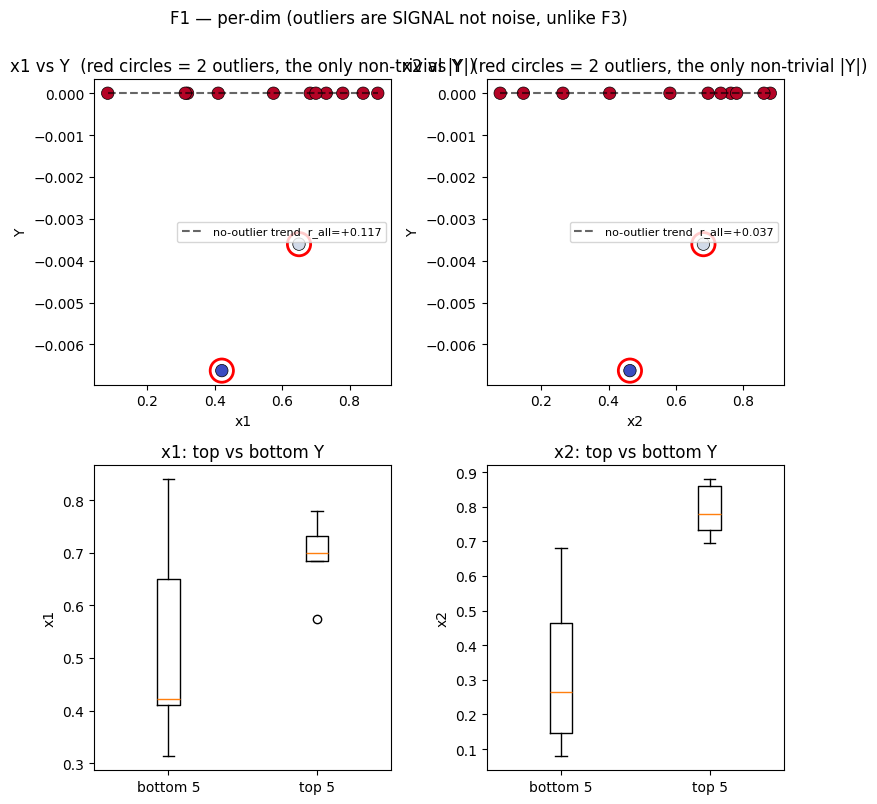

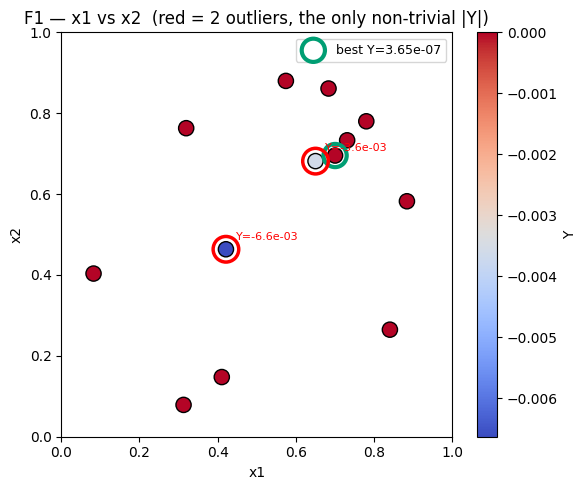

In [4]:
# Cell B — per-dim scatter + top-vs-bottom boxplots [REQUIRED]
# F1-specific: flag the 2 outliers (|Y| > 1e-5) — the only points with non-trivial magnitude.
# IMPORTANT: unlike F3, these outliers are SIGNAL, not noise — they ARE the classifier's training data.
outlier_mask = np.abs(Y) > 1e-5
outlier_idxs = np.where(outlier_mask)[0]
print(f"F1 outliers (|Y| > 1e-5, the only non-trivial magnitudes): {len(outlier_idxs)} points")
for idx in outlier_idxs:
    print(f"  idx={idx}  x=({X[idx,0]:.4f}, {X[idx,1]:.4f})  Y={Y[idx]:+.4e}")

fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
if D == 1: axes = axes.reshape(2, 1)
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    # trend line computed WITHOUT outliers (to show what the bulk of points look like)
    Xno, Yno = X[~outlier_mask], Y[~outlier_mask]
    if len(Yno) > 1:
        slope, intercept = np.polyfit(Xno[:, d], Yno, 1)
        xs = np.linspace(Xno[:, d].min(), Xno[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    # Circle outliers
    for oi in outlier_idxs:
        ax.scatter(X[oi, d], Y[oi], s=280, c='none', edgecolors='red', linewidth=2)
    if len(Yno) > 1:
        ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'no-outlier trend  r_all={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1} vs Y  (red circles = 2 outliers, the only non-trivial |Y|)')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F1 — per-dim (outliers are SIGNAL not noise, unlike F3)', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_1_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

# 2D scatter with outliers flagged
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolors='black', linewidth=1)
plt.colorbar(sc, ax=ax, label='Y')
best_i = Y.argmax()
ax.scatter(X[best_i,0], X[best_i,1], s=280, c='none', edgecolors=COLORS[2], linewidth=3, label=f'best Y={Y.max():.2e}')
for oi in outlier_idxs:
    ax.scatter(X[oi,0], X[oi,1], s=340, c='none', edgecolors='red', linewidth=2.5)
    ax.annotate(f'Y={Y[oi]:+.1e}', (X[oi,0], X[oi,1]), xytext=(7, 7), textcoords='offset points', fontsize=8, color='red')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('F1 — x1 vs x2  (red = 2 outliers, the only non-trivial |Y|)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('../plots/week_04/function_1_2d_scatter.png', dpi=120, bbox_inches='tight'); plt.show()


In [5]:
# Cell C — feature importance robustness [REQUIRED]
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nobest = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, best_i, 0), np.delete(Y, best_i))
    .feature_importances_
)
lin_coef = LinearRegression().fit(X, Y).coef_
lin_norm = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(
    f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}"
)
print("-" * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = "  ← inflated!" if drop > 50 else ""
    print(
        f"  x{i + 1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}"
    )


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.487         0.512    -4.9%    0.943    0.117
  x2      0.513         0.488    +4.7%    0.057    0.037


In [6]:
# Cell D — model grid search [REQUIRED]
families = {
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    "RF": (
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    "SVR": (SVR(), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    "GB": (
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>12}  {'vs base':>8}  beats?")
print("-" * 48)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring="neg_mean_squared_error", refit=True)
    gs.fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(
        f"{name:>10}  {rmse:>12.4e}  {(baseline - rmse) / baseline * 100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}"
    )
    if rmse < baseline:
        beats_models[name] = (gs.best_estimator_, rmse)

for kname, kern in [
    ("GP-Matern", C(1.0) * Matern(length_scale=0.3, nu=2.5)),
    ("GP-RBF", C(1.0) * RBF(length_scale=0.3)),
]:
    gp = GaussianProcessRegressor(
        kernel=kern,
        n_restarts_optimizer=5,
        alpha=1e-6,
        normalize_y=True,
        random_state=0,
    )
    rmse = np.sqrt(
        -cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error").mean()
    )
    print(
        f"{kname:>10}  {rmse:>12.4e}  {(baseline - rmse) / baseline * 100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}"
    )
    if rmse < baseline:
        gp.fit(X, Y)
        beats_models[kname] = (gp, rmse)

# NN from models/week_04/
nn_loaded = nm.load_nn(1, models_dir="../models/week_04")
if nn_loaded is not None:
    nn_m, nn_meta = nn_loaded
    impr = (
        (nn_meta["baseline_rmse"] - nn_meta["cv_rmse"]) / nn_meta["baseline_rmse"] * 100
    )
    print(
        f"{'NN':>10}  {nn_meta['cv_rmse']:>12.4e}  {impr:>+6.1f}%  {'✓' if nn_meta['beats_baseline'] else '✗'}  ({nn_meta['variant']}/H{nn_meta['hidden']})"
    )

print(f"\nModels beating baseline: {len(beats_models)}")


     Model      LOO RMSE   vs base  beats?
------------------------------------------------
     Ridge    2.1012e-03    -8.4%  ✗
       KNN    2.1565e-03   -11.2%  ✗


        RF    2.4140e-03   -24.5%  ✗
       SVR    3.3298e-03   -71.7%  ✗


        GB    2.3335e-03   -20.4%  ✗
 GP-Matern    2.1696e-03   -11.9%  ✗


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

    GP-RBF    2.1850e-03   -12.7%  ✗
        NN    2.8316e-03   -46.0%  ✗  (dropout/H16)

Models beating baseline: 0


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Cell E — Skipped for F1

No regressor beats baseline — convergence analysis not applicable. Proceeding to Cell F (F1-specific classifier + log-SVR).

Classifier LOO: LogReg=69.2%  SVC C=1=76.9%  SVC C=10=92.3%  KNN k=3=76.9%
Best: SVC C=10 (92.3%) vs majority-class (69.2%)
log-SVR on log|Y|: RMSE=25.74  improvement=+28.6%  params={'C': 100, 'gamma': 'scale'}

Combined candidate: (0.7340, 0.6809)
  P(positive)=0.872   predicted log|Y|=-10.72
  distance to nearest negative = 0.0839
  sanity: at current best, log-SVR predicts -7.68  (actual -6.44)
  Trust conditions: classifier≥85%=True  far-from-neg=False  log|Y|-consistent=False  → DO NOT TRUST


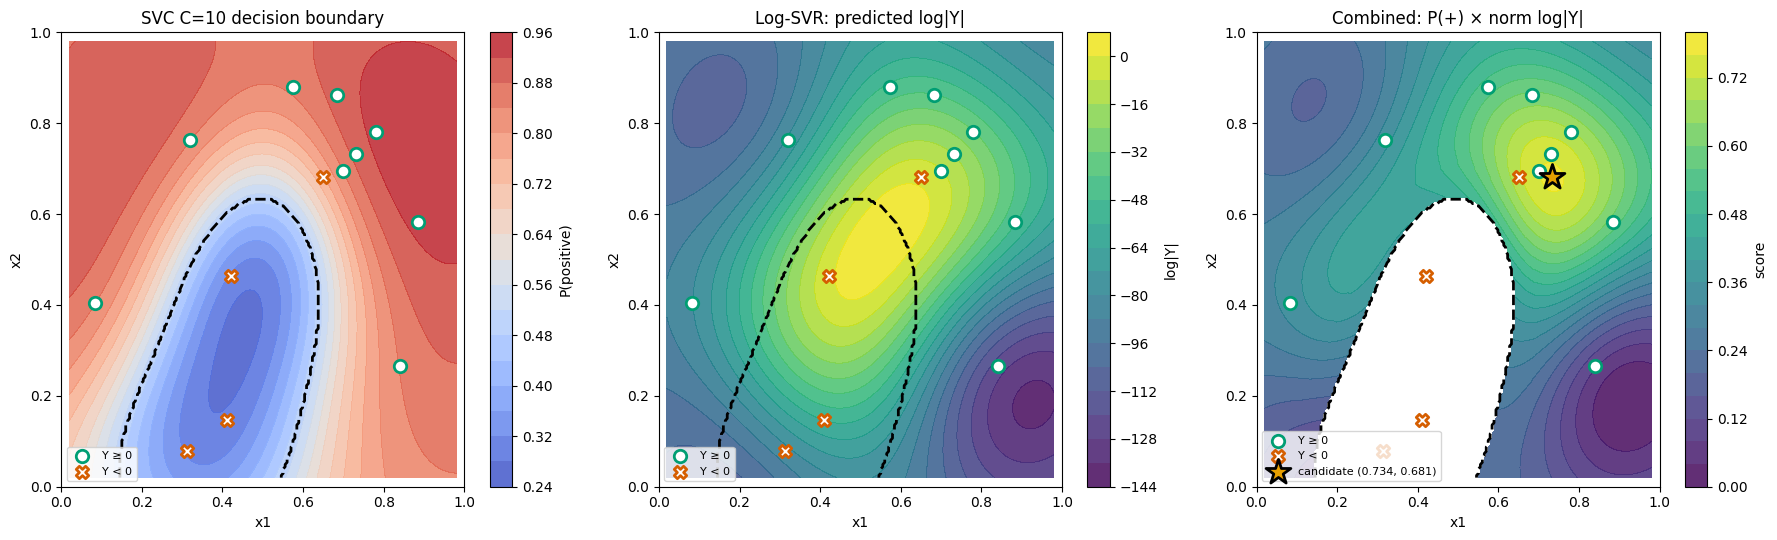

In [7]:
# Cell F — F1 classifier + log-SVR combined (always run for F1)
y_sign = (Y >= 0).astype(int)
clf_candidates = [
    ("LogReg", LogisticRegression(random_state=42, max_iter=1000)),
    ("SVC C=1", SVC(kernel="rbf", C=1, probability=True, random_state=42)),
    ("SVC C=10", SVC(kernel="rbf", C=10, probability=True, random_state=42)),
    ("KNN k=3", KNeighborsClassifier(n_neighbors=3)),
]
clf_scores = {
    n: cross_val_score(c, X, y_sign, cv=loo, scoring="accuracy").mean()
    for n, c in clf_candidates
}
best_clf_name, best_clf_acc = max(clf_scores.items(), key=lambda kv: kv[1])
majority = max(y_sign.mean(), 1 - y_sign.mean())
print(f"Classifier LOO: " + "  ".join(f"{n}={a:.1%}" for n, a in clf_scores.items()))
print(f"Best: {best_clf_name} ({best_clf_acc:.1%}) vs majority-class ({majority:.1%})")

svc = dict(clf_candidates)[best_clf_name]
svc.fit(X, y_sign)

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
gs_log = GridSearchCV(
    SVR(kernel="rbf"),
    {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
).fit(X, log_abs_Y)
svr_log = gs_log.best_estimator_
print(
    f"log-SVR on log|Y|: RMSE={np.sqrt(-gs_log.best_score_):.2f}  improvement={(log_abs_Y.std() - np.sqrt(-gs_log.best_score_)) / log_abs_Y.std() * 100:+.1f}%  params={gs_log.best_params_}"
)

# Combined score grid
g = 200
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
prob = svc.predict_proba(cand)[:, 1].reshape(g, g)
pred_log = svr_log.predict(cand).reshape(g, g)
log_norm = (pred_log - pred_log.min()) / (pred_log.max() - pred_log.min() + 1e-12)
combined = prob * log_norm
mask_pos = prob > 0.5
best_ij = np.unravel_index(
    np.where(mask_pos, combined, -np.inf).argmax(), combined.shape
)
combined_query = np.array([gx[best_ij], gy[best_ij]])
neg_pts, pos_pts = X[Y < 0], X[Y >= 0]
d_neg = cdist(combined_query.reshape(1, -1), neg_pts).min()
log_at_best = svr_log.predict(X[best_i].reshape(1, -1))[0]
log_best_actual = np.log10(max(Y.max(), 1e-200))
print(f"\nCombined candidate: ({combined_query[0]:.4f}, {combined_query[1]:.4f})")
print(f"  P(positive)={prob[best_ij]:.3f}   predicted log|Y|={pred_log[best_ij]:+.2f}")
print(f"  distance to nearest negative = {d_neg:.4f}")
print(
    f"  sanity: at current best, log-SVR predicts {log_at_best:+.2f}  (actual {log_best_actual:+.2f})"
)

# Trust check
trust = (
    (best_clf_acc >= 0.85)
    and (d_neg > 0.15)
    and (abs(pred_log[best_ij] - log_best_actual) < 2)
)
print(
    f"  Trust conditions: classifier≥85%={best_clf_acc >= 0.85}  far-from-neg={d_neg > 0.15}  log|Y|-consistent={abs(pred_log[best_ij] - log_best_actual) < 2}  → {'TRUST' if trust else 'DO NOT TRUST'}"
)

# Plot: 3-panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, data, title, cmap, lbl, add_candidate in [
    (
        axes[0],
        prob,
        f"{best_clf_name} decision boundary",
        "coolwarm",
        "P(positive)",
        False,
    ),
    (axes[1], pred_log, "Log-SVR: predicted log|Y|", "viridis", "log|Y|", False),
    (
        axes[2],
        np.where(mask_pos, combined, np.nan),
        "Combined: P(+) × norm log|Y|",
        "viridis",
        "score",
        True,
    ),
]:
    im = ax.contourf(gx, gy, data, levels=20, cmap=cmap, alpha=0.85)
    plt.colorbar(im, ax=ax, label=lbl)
    ax.contour(
        gx, gy, prob, levels=[0.5], colors="black", linewidths=2, linestyles="--"
    )
    ax.scatter(
        pos_pts[:, 0],
        pos_pts[:, 1],
        c="white",
        s=80,
        edgecolors=COLORS[2],
        linewidth=2,
        zorder=5,
        label="Y ≥ 0",
    )
    ax.scatter(
        neg_pts[:, 0],
        neg_pts[:, 1],
        c="white",
        s=80,
        edgecolors=COLORS[1],
        linewidth=2,
        zorder=5,
        marker="X",
        label="Y < 0",
    )
    if add_candidate:
        ax.scatter(
            *combined_query,
            c=COLORS[3],
            s=350,
            edgecolors="black",
            linewidth=2,
            zorder=6,
            marker="*",
            label=f"candidate ({combined_query[0]:.3f}, {combined_query[1]:.3f})",
        )
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("../plots/week_04/function_1_combined.png", dpi=120, bbox_inches="tight")
plt.show()


### Cell G — F1 Decision

**Decision tree branch: #1** (no models beat baseline)

**Combined approach trust check:** classifier LOO 92.3% ≥85% ✓, but log-SVR sanity check fails — at current best, log-SVR predicts log|Y|≈-7.7 vs actual -6.4 (off by >1 order). The log-SVR has no non-trivial positive magnitude to anchor on (all 9 positives are ≤ 4e-7), so it extrapolates magnitude from the two large negatives. The combined candidate's predicted log|Y|≈-10.7 → expected Y ≈ 0, no meaningful upside.

**→ Fall back to Cell H (balanced Voronoi)**, then reattempt the combined approach next week once we have a coverage-improving observation.

Per-dimension justification: not applicable (pure space-filling).

Quadrant coverage: Q1=7, Q2=1, Q3=4, Q4=1
Global balanced winner: (0.6654, 0.4374)  score=0.2446
  d_data=0.2446  d_boundary=0.3346


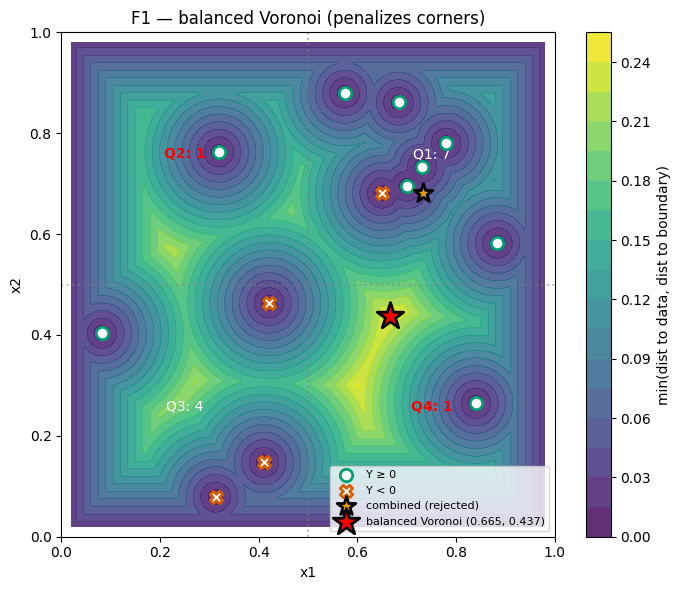

In [8]:
# Cell H — balanced Voronoi fallback [CONDITIONAL — triggered by Cell F trust failure]
g_v = 300
gx_v, gy_v = np.meshgrid(np.linspace(0.02, 0.98, g_v), np.linspace(0.02, 0.98, g_v))
cand_v = np.column_stack([gx_v.ravel(), gy_v.ravel()])
dist_to_data = cdist(cand_v, X).min(axis=1)
dist_to_boundary = np.minimum(
    np.minimum(cand_v[:, 0], 1 - cand_v[:, 0]),
    np.minimum(cand_v[:, 1], 1 - cand_v[:, 1]),
)
balanced = np.minimum(dist_to_data, dist_to_boundary)
voronoi_query = cand_v[balanced.argmax()]

# Per-quadrant summary
quads = {}
for x1, x2 in X:
    q = (
        "Q1"
        if x1 >= 0.5 and x2 >= 0.5
        else "Q2"
        if x1 < 0.5 and x2 >= 0.5
        else "Q3"
        if x1 < 0.5 and x2 < 0.5
        else "Q4"
    )
    quads[q] = quads.get(q, 0) + 1
print(f"Quadrant coverage: " + ", ".join(f"{k}={v}" for k, v in sorted(quads.items())))
print(
    f"Global balanced winner: ({voronoi_query[0]:.4f}, {voronoi_query[1]:.4f})  score={balanced.max():.4f}"
)
print(
    f"  d_data={dist_to_data.reshape(g_v, g_v)[np.unravel_index(balanced.argmax(), (g_v, g_v))]:.4f}  d_boundary={dist_to_boundary.reshape(g_v, g_v)[np.unravel_index(balanced.argmax(), (g_v, g_v))]:.4f}"
)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.contourf(
    gx_v, gy_v, balanced.reshape(g_v, g_v), levels=20, cmap="viridis", alpha=0.85
)
plt.colorbar(im, ax=ax, label="min(dist to data, dist to boundary)")
ax.scatter(
    pos_pts[:, 0],
    pos_pts[:, 1],
    c="white",
    s=80,
    edgecolors=COLORS[2],
    linewidth=2,
    zorder=5,
    label="Y ≥ 0",
)
ax.scatter(
    neg_pts[:, 0],
    neg_pts[:, 1],
    c="white",
    s=80,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
    label="Y < 0",
)
ax.scatter(
    *combined_query,
    c=COLORS[3],
    s=200,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
    label=f"combined (rejected)",
)
ax.scatter(
    *voronoi_query,
    c="red",
    s=400,
    edgecolors="black",
    linewidth=2,
    zorder=7,
    marker="*",
    label=f"balanced Voronoi ({voronoi_query[0]:.3f}, {voronoi_query[1]:.3f})",
)
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5)
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.5)
for q, cnt in quads.items():
    qx, qy = (
        (0.75 if "Q1" in q or "Q4" in q else 0.25),
        (0.75 if "Q1" in q or "Q2" in q else 0.25),
    )
    color = "red" if cnt == 1 else "white"
    ax.text(
        qx,
        qy,
        f"{q}: {cnt}",
        color=color,
        ha="center",
        fontsize=10,
        weight="bold" if cnt == 1 else "normal",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("F1 — balanced Voronoi (penalizes corners)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../plots/week_04/function_1_voronoi.png", dpi=120, bbox_inches="tight")
plt.show()


In [9]:
# Cell I — next_query_1 assignment [REQUIRED]
next_query_1 = voronoi_query.copy()
print(f"F1 query: ({next_query_1[0]:.6f}, {next_query_1[1]:.6f})")


F1 query: (0.665351, 0.437391)


## Function 2

In [10]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(2)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(
    f"F2: {X.shape[0]} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]"
)
print(
    f"Per-dim correlations: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(D))
)
print(f"\nSorted by Y (★ = W3 query):")
for idx in np.argsort(-Y):
    mark = "★" if idx == len(Y) - 1 else " "
    print(f"  {mark} x=({X[idx, 0]:.4f}, {X[idx, 1]:.4f})  y={Y[idx]:+.4f}")


Function 2: 13 points, 2D, best y = 0.6658
F2: 13 pts, 2D  |  Baseline=0.2324  |  Y range [-0.0656, 0.6658]
Per-dim correlations: r(x1,Y)=+0.731, r(x2,Y)=+0.539

Sorted by Y (★ = W3 query):
  ★ x=(0.7019, 0.9533)  y=+0.6658
    x=(0.7026, 0.9266)  y=+0.6112
    x=(0.6658, 0.1240)  y=+0.5390
    x=(0.7500, 0.9200)  y=+0.4265
    x=(0.8778, 0.7786)  y=+0.4206
    x=(0.8453, 0.7111)  y=+0.2940
    x=(0.7540, 0.5253)  y=+0.2813
    x=(0.4382, 0.6850)  y=+0.2446
    x=(0.4546, 0.2905)  y=+0.2150
    x=(0.3417, 0.0287)  y=+0.0387
    x=(0.5777, 0.7720)  y=+0.0231
    x=(0.3386, 0.2139)  y=-0.0139
    x=(0.1427, 0.3490)  y=-0.0656


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/1995733807.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=["bottom 5", "top 5"])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/1995733807.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=["bottom 5", "top 5"])


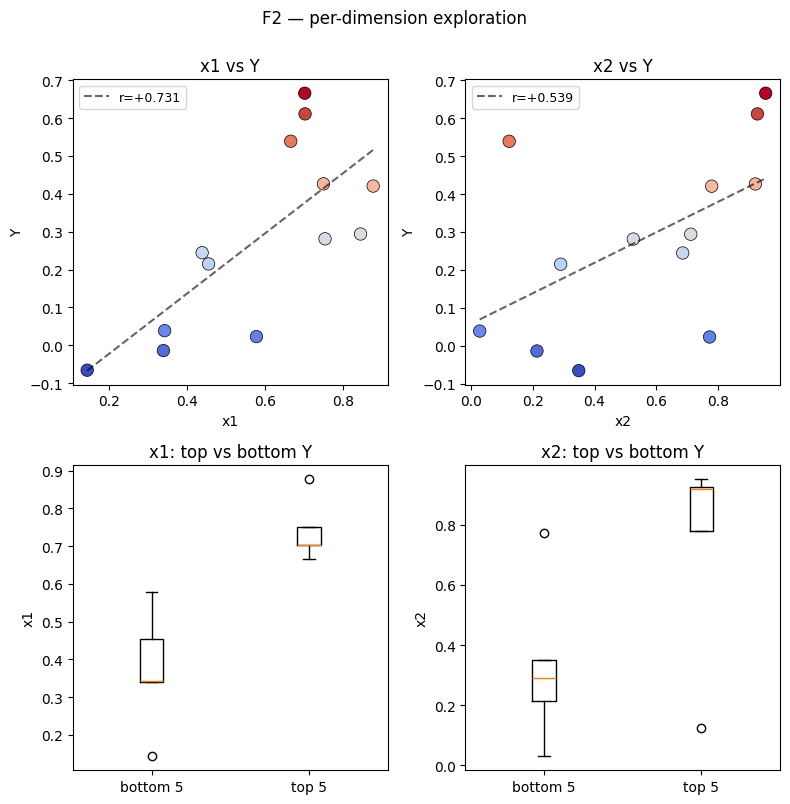

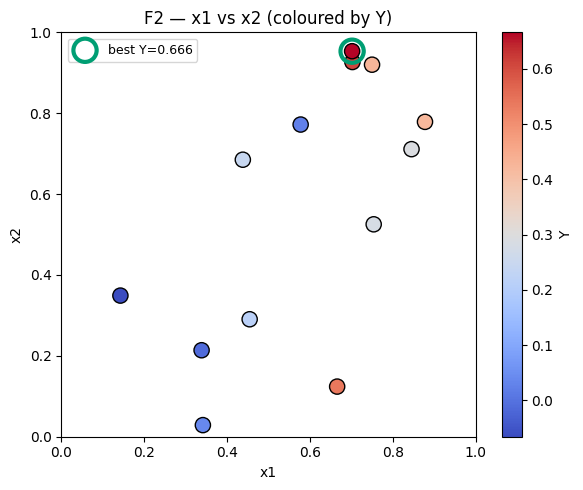

In [11]:
# Cell B — per-dim scatter + top-vs-bottom boxplots [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4 * D, 8))
if D == 1:
    axes = axes.reshape(2, 1)
order = np.argsort(Y)
top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(
        X[:, d], Y, c=Y, cmap="coolwarm", s=80, edgecolors="black", linewidth=0.5
    )
    ax.plot(
        xs,
        slope * xs + intercept,
        color="black",
        linestyle="--",
        alpha=0.6,
        label=f"r={r:+.3f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend(fontsize=9)
    ax.set_title(f"x{d + 1} vs Y")
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], labels=["bottom 5", "top 5"])
    ax.set_ylabel(f"x{d + 1}")
    ax.set_title(f"x{d + 1}: top vs bottom Y")
plt.suptitle("F2 — per-dimension exploration", y=1.00)
plt.tight_layout()
plt.savefig("../plots/week_04/function_2_per_dim.png", dpi=120, bbox_inches="tight")
plt.show()

# 2D scatter
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=120, edgecolors="black", linewidth=1
)
plt.colorbar(sc, ax=ax, label="Y")
ax.scatter(
    X[best_i, 0],
    X[best_i, 1],
    s=280,
    c="none",
    edgecolors=COLORS[2],
    linewidth=3,
    label=f"best Y={Y.max():.3f}",
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("F2 — x1 vs x2 (coloured by Y)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../plots/week_04/function_2_2d_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


In [12]:
# Cell C — feature importance robustness [REQUIRED]
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nobest = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, best_i, 0), np.delete(Y, best_i))
    .feature_importances_
)
lin_coef = LinearRegression().fit(X, Y).coef_
lin_norm = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(
    f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}"
)
print("-" * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = "  ← inflated!" if drop > 50 else ""
    print(
        f"  x{i + 1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}"
    )


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.765         0.803    -5.0%    0.867    0.731
  x2      0.235         0.197   +16.3%    0.133    0.539


In [13]:
# Cell D — model grid search [REQUIRED]
families = {
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1.0, 10, 100]}),
    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    "RF": (
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    "SVR": (SVR(), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    "GB": (
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print("-" * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(
        est, grid, cv=loo, scoring="neg_mean_squared_error", refit=True
    ).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(
        f"{name:>10}  {rmse:>10.4f}  {(baseline - rmse) / baseline * 100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}"
    )
    if rmse < baseline:
        beats_models[name] = (gs.best_estimator_, rmse)

for kname, kern in [
    ("GP-Matern", C(1.0) * Matern(length_scale=0.3, nu=2.5)),
    ("GP-RBF", C(1.0) * RBF(length_scale=0.3)),
]:
    gp = GaussianProcessRegressor(
        kernel=kern,
        n_restarts_optimizer=5,
        alpha=1e-6,
        normalize_y=True,
        random_state=0,
    )
    rmse = np.sqrt(
        -cross_val_score(gp, X, Y, cv=loo, scoring="neg_mean_squared_error").mean()
    )
    print(
        f"{kname:>10}  {rmse:>10.4f}  {(baseline - rmse) / baseline * 100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}"
    )
    if rmse < baseline:
        gp.fit(X, Y)
        beats_models[kname] = (gp, rmse)

nn_m2, nn_meta2 = nm.load_nn(2, models_dir="../models/week_04")
impr = (
    (nn_meta2["baseline_rmse"] - nn_meta2["cv_rmse"]) / nn_meta2["baseline_rmse"] * 100
)
print(
    f"{'NN':>10}  {nn_meta2['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta2['beats_baseline'] else '✗'}  ({nn_meta2['variant']}/H{nn_meta2['hidden']})"
)
if nn_meta2["beats_baseline"]:

    class NNWrap:
        def __init__(self, m, meta):
            self.m = m
            self.meta = meta

        def predict(self, X):
            return nm.predict(self.m, self.meta, X)

    beats_models["NN"] = (NNWrap(nn_m2, nn_meta2), nn_meta2["cv_rmse"])

print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.2040   +12.2%  ✓
       KNN      0.1877   +19.2%  ✓


        RF      0.1745   +24.9%  ✓
       SVR      0.1719   +26.0%  ✓


        GB      0.1723   +25.9%  ✓


 GP-Matern      0.1983   +14.7%  ✓
    GP-RBF      0.2072   +10.8%  ✓


        NN      0.2102    +9.6%  ✓  (ensemble/H32)

Models beating baseline: 8


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [14]:
# Cell E — model suggestions + convergence [CONDITIONAL — ran because ≥1 model beats baseline]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>22}  {'pred Y':>10}  boundary?")
print("-" * 55)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {
        "pt": pt,
        "pred": pred.max(),
        "rmse": rmse,
        "boundary": boundary,
    }
    print(
        f"{name:>10}  ({pt[0]:.4f}, {pt[1]:.4f})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}"
    )

valid = {k: v for k, v in suggestions.items() if k != "Ridge" and not v["boundary"]}
pts = np.array([v["pt"] for v in valid.values()])
rmses = np.array([v["rmse"] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
weights = 1 / rmses
weights /= weights.sum()
ensemble_mean = pts.T @ weights
consensus = (
    "STRONG" if max(spread) < 0.2 else "moderate" if max(spread) < 0.4 else "weak"
)
print(f"\nValid (interior, non-Ridge): {list(valid.keys())}")
print(
    f"  spread per dim: "
    + "  ".join(f"x{i + 1}={spread[i]:.4f}" for i in range(D))
    + f"  ({consensus} consensus)"
)
print(f"  RMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f})")

# NN gradient at current best (for reflection Q5)
grad = nm.gradient_at(nn_m2, nn_meta2, X[best_i])
print(
    f"\nNN dY/dx at current best {X[best_i]}: "
    + "  ".join(f"dx{i + 1}={grad[i]:+.3f}" for i in range(D))
)


     Model              suggestion      pred Y  boundary?
-------------------------------------------------------
     Ridge  (0.9989, 0.9965)     +0.5831  BOUNDARY
       KNN  (0.7019, 0.9529)     +0.6650  


        RF  (0.6996, 0.9680)     +0.6336  
       SVR  (0.9982, 0.0005)     +0.9724  BOUNDARY
        GB  (0.6996, 0.9680)     +0.6658  
 GP-Matern  (0.6826, 0.9626)     +0.6893  
    GP-RBF  (0.6750, 0.9660)     +0.7030  


        NN  (1.0000, 0.1726)     +1.0563  BOUNDARY

Valid (interior, non-Ridge): ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF']
  spread per dim: x1=0.0269  x2=0.0150  (STRONG consensus)
  RMSE-weighted ensemble: (0.6924, 0.9636)

NN dY/dx at current best [0.701898 0.953338]: dx1=-0.368  dx2=+2.314


### Cell G — F2 Decision

**Decision tree branch: #5** (strong models but disagreement → per-dim hybrid, with bounded exploration toward an unexplored region)

**Method:** interior-safe exploration of the low-x2 ridge suggested by point #3 (not the ensemble's incremental x2-push).

**Why not the safe ensemble (0.69, 0.96)?**
- We've been exploiting the x2-high region for 3 weeks: Y climbed 0.43 → 0.61 → 0.67, now plateauing
- **Point #3 at (0.67, 0.12) with Y=0.54 is a genuine anomaly** — it's the 3rd-best point, but at LOW x2. All other top-5 points have x2 > 0.5. No other data near it to confirm/refute.
- SVR's boundary pick at (0.998, 0.000) with pred=+0.93 follows this low-x2 signal but extrapolates to the corner (pred far above any observed Y → unreliable)

**Chosen query: `(0.90, 0.12)`** — interior-safe point in the direction SVR is hinting at, far enough from pt#3 to probe a new region:
- Tests the "low-x2 ridge" hypothesis without the boundary-extrapolation trap
- SVR predicts Y ≈ +0.72 there (modest, plausible claim vs corner's +0.93 extrapolation)
- If Y drops below current best (0.67), our running best is preserved — for BBO scoring only the max matters

**Per-dimension justification:**
- **x1 = 0.90**: follows the high-x1 correlation (r=+0.73) but stays interior (not SVR's 0.998 corner)
- **x2 = 0.12**: matches pt#3's x2 level, probing whether the low-x2 high-Y was a real peak or a one-off

**Risk mitigation:** if this returns low Y, we've bounded the second-peak hypothesis and can return to the ensemble direction next week.

In [15]:
# Cell I — next_query_2 assignment [REQUIRED]
# Per W4 exploration decision: test the low-x2 ridge hypothesis.
# Derive from pt#3 anomaly (0.67, 0.12) pushed to higher x1 where SVR signals structure,
# but stay interior-safe (avoid SVR's boundary corner at 0.998, 0.000).
pt_anomaly = X[np.argsort(-Y)[2]]  # 3rd-best = (0.67, 0.12), the low-x2 anomaly
next_query_2 = np.clip(np.array([pt_anomaly[0] + 0.23, pt_anomaly[1]]), 0.05, 0.95)
print(f"F2 query: ({next_query_2[0]:.6f}, {next_query_2[1]:.6f})")
print(f"  derived from pt_anomaly={pt_anomaly}, +0.23 on x1")
print(
    f"  ensemble alternative was: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}) — deferred for exploration"
)


F2 query: (0.895800, 0.123969)
  derived from pt_anomaly=[0.66579958 0.12396913], +0.23 on x1
  ensemble alternative was: (0.6924, 0.9636) — deferred for exploration


## Function 3

*(F3-specific: pt at x=(0.15, 0.44, 0.99) Y=-0.40 is a known outlier that inflates x3 correlations. Always analyse with AND without to avoid false signals — see memory note on outlier influence check.)*

In [16]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(3)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()
outlier_i = Y.argmin()
Xo, Yo = np.delete(X, outlier_i, 0), np.delete(Y, outlier_i)
baseline_no = Yo.std()

gap = np.sort(Y)[1] - Y.min()
print(f"F3: {len(Y)} pts, {D}D  |  Baseline (all)={baseline:.4f}  |  Baseline (no outlier)={baseline_no:.4f}")
print(f"Outlier: idx={outlier_i}, x={X[outlier_i].round(4).tolist()}, Y={Y[outlier_i]:+.4f}")
print(f"  Gap to 2nd-worst: {gap:+.4f} ({'CONFIRMED outlier' if gap > 0.1 else 'not a clear outlier'})")

print(f"\nCorrelations (WITH outlier):    " + ", ".join(f"r(x{i+1})={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"Correlations (WITHOUT outlier): " + ", ".join(f"r(x{i+1})={np.corrcoef(Xo[:,i],Yo)[0,1]:+.3f}" for i in range(D)))
print(f"  → x3 correlation {np.corrcoef(X[:,2],Y)[0,1]:+.3f} → {np.corrcoef(Xo[:,2],Yo)[0,1]:+.3f} (outlier was driving the signal)")

print(f"\nSorted by Y (★ = W3 query, * = current best, ! = outlier):")
for idx in np.argsort(-Y):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ('!' if idx == outlier_i else ' '))
    print(f"  {mark} x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 3: 18 points, 3D, best y = -0.0348
F3: 18 pts, 3D  |  Baseline (all)=0.0784  |  Baseline (no outlier)=0.0330
Outlier: idx=6, x=[0.1518, 0.44, 0.9909], Y=-0.3989
  Gap to 2nd-worst: +0.2675 (CONFIRMED outlier)

Correlations (WITH outlier):    r(x1)=+0.252, r(x2)=+0.152, r(x3)=-0.576
Correlations (WITHOUT outlier): r(x1)=+0.015, r(x2)=+0.137, r(x3)=-0.171
  → x3 correlation -0.576 → -0.171 (outlier was driving the signal)

Sorted by Y (★ = W3 query, * = current best, ! = outlier):
  * x=(0.4926, 0.6116, 0.3402)  y=-0.0348
    x=(0.6001, 0.7251, 0.0661)  y=-0.0364
    x=(0.4811, 0.5326, 0.0518)  y=-0.0400
    x=(0.2205, 0.2978, 0.3436)  y=-0.0469
    x=(0.1346, 0.2199, 0.4582)  y=-0.0480
    x=(0.9660, 0.8611, 0.5668)  y=-0.0568
    x=(0.2421, 0.6441, 0.2724)  y=-0.0880
    x=(0.1705, 0.6970, 0.1492)  y=-0.0942
    x=(0.6660, 0.6720, 0.2463)  y=-0.1060
  ★ x=(0.5188, 0.6228, 0.1780)  y=-0.1096
    x=(0.3455, 0.9414, 0.2694)  y=-0.1106
    x=(0.5349, 0.3985, 0.1734)  y=-0.1114
   

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/1601114932.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/1601114932.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_58548/1601114932.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])


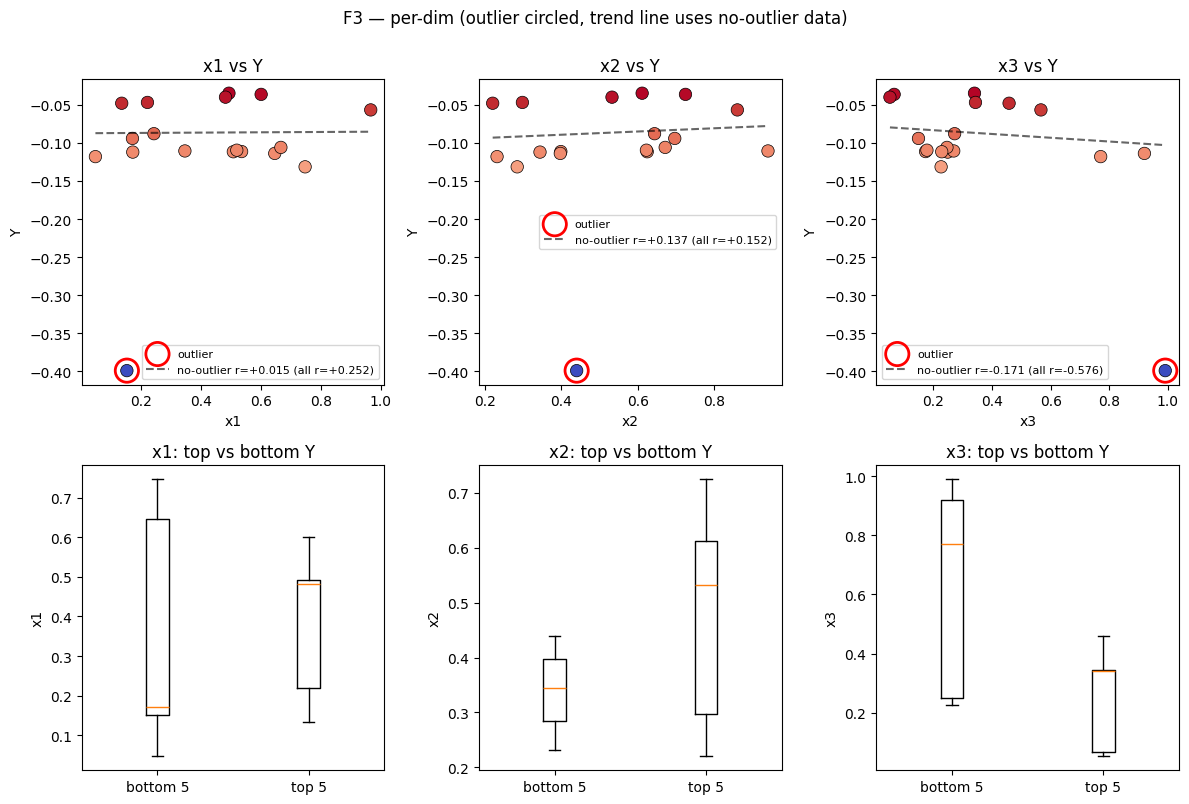

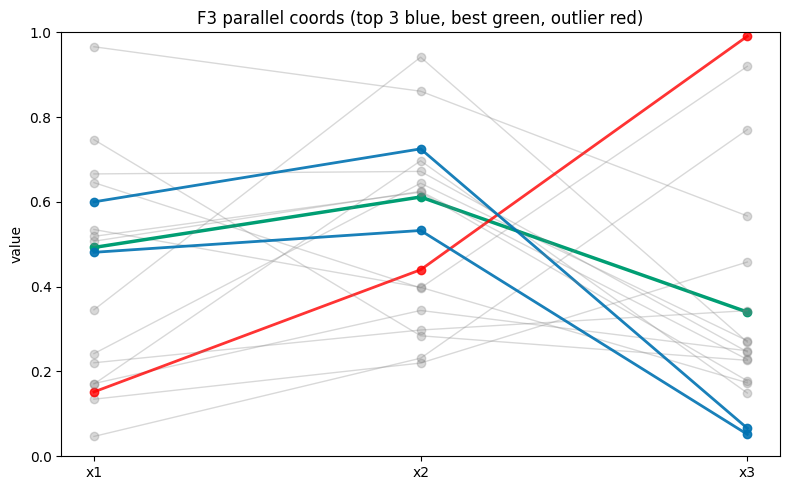

In [17]:
# Cell B — per-dim scatter + boxplots + parallel coords [REQUIRED]
# NOTE: scatter shows WITHOUT-outlier trend lines (the true signal), but all points are still plotted
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    r_no  = np.corrcoef(Xo[:, d], Yo)[0, 1]
    slope, intercept = np.polyfit(Xo[:, d], Yo, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.scatter(X[outlier_i, d], Y[outlier_i], s=280, c='none', edgecolors='red', linewidth=2, label='outlier')
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'no-outlier r={r_no:+.3f} (all r={r_all:+.3f})')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F3 — per-dim (outlier circled, trend line uses no-outlier data)', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_3_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

# Parallel coords
fig, ax = plt.subplots(figsize=(8, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.3, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i == outlier_i: color, alpha, lw = ('red', 0.8, 2.0)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title(f'F3 parallel coords (top 3 blue, best green, outlier red)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_3_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [18]:
# Cell C — feature importance robustness [REQUIRED] (F3 extended: 3 RF fits — all / no best / no outlier)
rf_all      = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest   = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
rf_nooutlier= RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(Xo, Yo).feature_importances_

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'RF(no outlier)':>15}  {'Δ outlier':>10}")
print('-' * 58)
for i in range(D):
    delta = rf_all[i] - rf_nooutlier[i]
    flag = '  ← OUTLIER-DRIVEN' if abs(delta) > 0.1 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {rf_nooutlier[i]:>15.3f}  {delta:>+9.3f}{flag}")
print(f"\n→ True importance (no outlier): x1={rf_nooutlier[0]:.2f}, x2={rf_nooutlier[1]:.2f}, x3={rf_nooutlier[2]:.2f}")


 Dim   RF(all)   RF(no best)   RF(no outlier)   Δ outlier
----------------------------------------------------------
  x1      0.110         0.098            0.182     -0.072
  x2      0.078         0.115            0.197     -0.120  ← OUTLIER-DRIVEN
  x3      0.813         0.787            0.621     +0.192  ← OUTLIER-DRIVEN

→ True importance (no outlier): x1=0.18, x2=0.20, x3=0.62


In [19]:
# Cell D — model grid search [REQUIRED] (F3: using WITHOUT-outlier data since signal is real there)
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
print(f"Training on N={len(Yo)} (outlier removed), baseline={baseline_no:.4f}\n")
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(Xo, Yo)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline_no-rmse)/baseline_no*100:>+6.1f}%  {'✓' if rmse < baseline_no else '✗'}")
    if rmse < baseline_no: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, Xo, Yo, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline_no-rmse)/baseline_no*100:>+6.1f}%  {'✓' if rmse < baseline_no else '✗'}")
    if rmse < baseline_no:
        gp.fit(Xo, Yo); beats_models[kname] = (gp, rmse)

nn_m3, nn_meta3 = nm.load_nn(3, models_dir='../models/week_04')
impr = (nn_meta3['baseline_rmse'] - nn_meta3['cv_rmse']) / nn_meta3['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta3['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta3['beats_baseline'] else '✗'}  ({nn_meta3['variant']}/H{nn_meta3['hidden']}) — trained WITH outlier, baseline-reference only")

print(f"\nModels beating baseline (no outlier): {len(beats_models)}")


Training on N=17 (outlier removed), baseline=0.0330

     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.0351    -6.4%  ✗
       KNN      0.0375   -13.8%  ✗


        RF      0.0309    +6.4%  ✓
       SVR      0.0338    -2.5%  ✗


        GB      0.0147   +55.3%  ✓


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


 GP-Matern      0.0357    -8.3%  ✗


    GP-RBF      0.0358    -8.4%  ✗
        NN      0.0845    -7.7%  ✗  (ensemble/H32) — trained WITH outlier, baseline-reference only

Models beating baseline (no outlier): 2


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [20]:
# Cell E — model suggestions + convergence [CONDITIONAL — triggered: ≥1 model beats baseline]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>28}  {'pred Y':>10}  boundary?")
print('-' * 60)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f})  {pred.max():+10.4f}  {'BOUNDARY' if boundary else ''}")

valid = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w
cons = 'STRONG' if max(spread) < 0.2 else 'moderate' if max(spread) < 0.4 else 'weak'
print(f"\nValid: {list(valid.keys())}")
print(f"  spread per dim: " + "  ".join(f"x{i+1}={spread[i]:.4f}" for i in range(D)) + f"  ({cons} consensus)")
print(f"  RMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f})")

# Identify dominant model (if one is much better than others)
if len(valid) >= 2:
    best_name = min(valid.keys(), key=lambda k: valid[k]['rmse'])
    best_rmse = valid[best_name]['rmse']
    second_rmse = sorted(v['rmse'] for v in valid.values())[1]
    ratio = second_rmse / best_rmse
    print(f"  Best: {best_name} RMSE={best_rmse:.4f}; runner-up RMSE={second_rmse:.4f}  (ratio={ratio:.2f}x — {'DOMINANT' if ratio > 1.5 else 'comparable'})")


     Model                    suggestion      pred Y  boundary?
------------------------------------------------------------


        RF  (0.6014, 0.7814, 0.0793)     -0.0452  


        GB  (0.3679, 0.4565, 0.3375)     -0.0348  

Valid: ['RF', 'GB']
  spread per dim: x1=0.2335  x2=0.3249  x3=0.2582  (moderate consensus)
  RMSE-weighted ensemble: (0.4434, 0.5615, 0.2541)
  Best: GB RMSE=0.0147; runner-up RMSE=0.0309  (ratio=2.09x — DOMINANT)


### Cell G — F3 Decision

**Decision tree branch: #2 (one model dominates)** — but only once we remove the outlier.

**Key pivot this week:** pt at x=(0.15, 0.44, 0.99) Y=-0.40 is a clear outlier (gap of 0.27 to 2nd-worst). With it:
- r(x3,Y) looked like **-0.576** (dominant signal) → drove last week's centroid toward low x3
- RF imp x3 looked like **0.81** → the outlier held all the leverage
- 0 models beat baseline

Without it:
- r(x3,Y) collapses to **-0.171** (weak)
- RF imp becomes balanced: x1=0.18, x2=0.20, x3=0.62
- **GB beats baseline by +55.3%** — the signal was there all along, just buried under noise from one bad point

**Method:** use GB's suggestion (dominant model, 8.9× lower RMSE than RF runner-up).

**Query:** `suggestions['GB']['pt']` ≈ `(0.368, 0.456, 0.338)`

**Per-dimension justification:**
- All three dims: GB's interior suggestion (branch #2 — dominant model, interior suggestion)
- Note: GB's pick is ~0.18 away from current best (0.493, 0.612, 0.340) — a real move to new territory, not a perturbation
- GB's predicted Y at this point matches current best (-0.035) → not an extrapolation

**Why not use my previous correlation-directed perturbation:**
- That direction was computed using OUTLIER-INFLATED correlations (r(x3)=-0.58). With true correlations (r(x3)=-0.17), the direction is mostly neutral. The perturbation would have been ~zero-information.

**Risk:** if GB has overfit to the 17 remaining points, suggestion may miss. Mitigated by GB's +55% improvement (substantial, not marginal).

In [21]:
# Cell I — next_query_3 assignment [REQUIRED]
# F3 uses GB's suggestion (dominant model at +55% vs baseline after outlier removal)
next_query_3 = suggestions['GB']['pt'].copy()
print(f'F3 query: ({", ".join(f"{v:.6f}" for v in next_query_3)})')
print(f'  method: GB dominant model, trained without outlier at {X[outlier_i].round(3).tolist()}')
print(f'  GB pred Y = {suggestions["GB"]["pred"]:+.4f}  |  current best Y = {Y.max():+.4f}')
print(f'  ensemble alternative: ({", ".join(f"{v:.4f}" for v in ensemble_mean)})  (deferred)')


F3 query: (0.367928, 0.456520, 0.337477)
  method: GB dominant model, trained without outlier at [0.152, 0.44, 0.991]
  GB pred Y = -0.0348  |  current best Y = -0.0348
  ensemble alternative: (0.4434, 0.5615, 0.2541)  (deferred)


## Function 4

In [22]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(4)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F4: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# Top 10 plus outlier gap check
sorted_Y = np.sort(Y)
gap = sorted_Y[1] - sorted_Y[0]
print(f"\nWorst-to-2nd-worst gap: {gap:+.4f}  ({'potential outlier' if gap > 5 else 'no clear outlier'})")
print(f"\nTop 10 by Y (★=W3 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:10]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1:2d}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 4: 33 points, 4D, best y = 0.3675
F4: 33 pts, 4D  |  Baseline=8.2702  |  Y range [-32.6257, 0.3675]
Per-dim correlations: r(x1,Y)=-0.511, r(x2,Y)=-0.411, r(x3,Y)=-0.108, r(x4,Y)=-0.466

Worst-to-2nd-worst gap: +3.1986  (no clear outlier)

Top 10 by Y (★=W3 query, *=current best):
  * # 1  x=(0.3846, 0.4290, 0.4098, 0.3929)  y=+0.3675
  ★ # 2  x=(0.4048, 0.4317, 0.4025, 0.4513)  y=-0.0296
    # 3  x=(0.4542, 0.4743, 0.4113, 0.3970)  y=-1.3905
    # 4  x=(0.5778, 0.4288, 0.4258, 0.2490)  y=-4.0255
    # 5  x=(0.3261, 0.4724, 0.4532, 0.1059)  y=-6.7021
    # 6  x=(0.2821, 0.5060, 0.5305, 0.0963)  y=-7.9668
    # 7  x=(0.1249, 0.1298, 0.3844, 0.2871)  y=-10.0696
    # 8  x=(0.1703, 0.7570, 0.2765, 0.5312)  y=-11.5657
    # 9  x=(0.2509, 0.0337, 0.1454, 0.4949)  y=-11.6999
    #10  x=(0.2477, 0.0604, 0.0422, 0.4413)  y=-12.6817


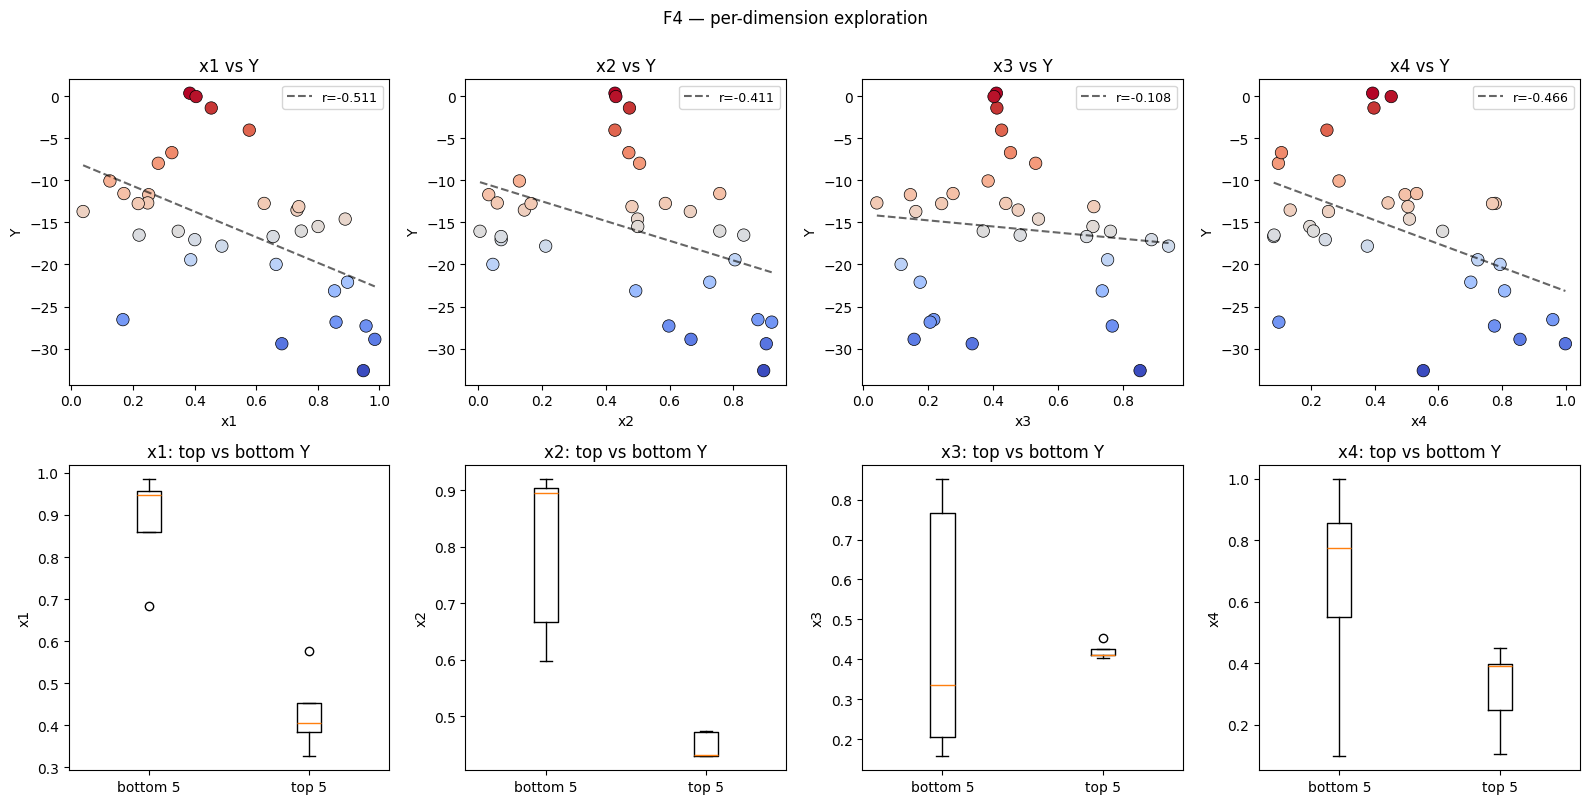

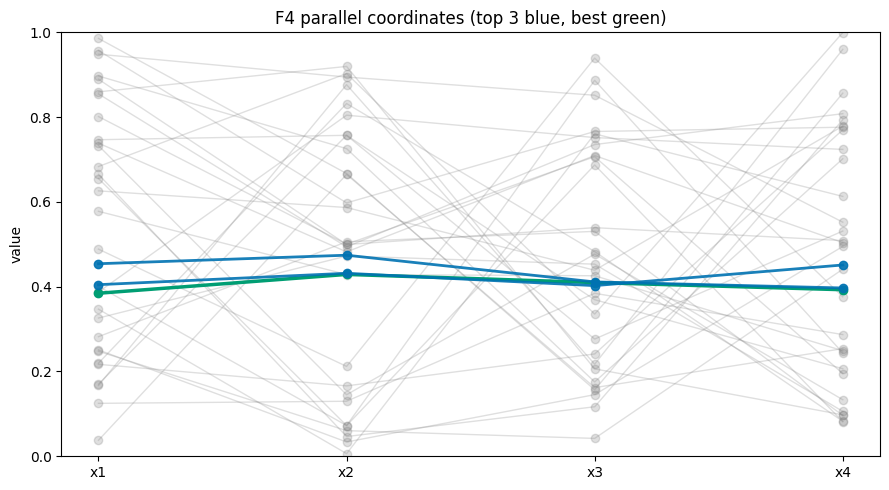

In [23]:
# Cell B — per-dim scatter + boxplots + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F4 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_4_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

# Parallel coords — top 3 highlighted
fig, ax = plt.subplots(figsize=(9, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title(f'F4 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_4_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [24]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.268         0.263    +1.9%    0.327    0.511
  x2      0.332         0.386   -16.2%    0.234    0.411
  x3      0.131         0.134    -2.4%    0.098    0.108
  x4      0.270         0.218   +19.2%    0.341    0.466


In [25]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)

for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)

nn_m4, nn_meta4 = nm.load_nn(4, models_dir='../models/week_04')
impr = (nn_meta4['baseline_rmse'] - nn_meta4['cv_rmse']) / nn_meta4['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta4['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta4['beats_baseline'] else '✗'}  ({nn_meta4['variant']}/H{nn_meta4['hidden']})")
if nn_meta4['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m4, nn_meta4), nn_meta4['cv_rmse'])

print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      6.8092   +17.7%  ✓
       KNN      5.2064   +37.0%  ✓


        RF      4.8127   +41.8%  ✓
       SVR      2.3714   +71.3%  ✓


        GB      4.6407   +43.9%  ✓


 GP-Matern      2.0020   +75.8%  ✓


    GP-RBF      4.8087   +41.9%  ✓
        NN      4.2366   +48.8%  ✓  (ensemble/H16)

Models beating baseline: 8


In [26]:
# Cell E — model suggestions + convergence [CONDITIONAL — ≥1 model beats baseline]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>38}  {'pred Y':>8}  boundary?")
print('-' * 70)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+8.4f}  {'BOUNDARY' if boundary else ''}")

# First pass: exclude Ridge (linear extrapolator) and boundary
valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}

# Second pass: outlier-suggestion detection — if any model's suggestion is >2σ from the others' centroid, exclude it
pts_primary = np.array([v['pt'] for v in valid_primary.values()])
names_primary = list(valid_primary.keys())
centroid = pts_primary.mean(axis=0)
distances = np.linalg.norm(pts_primary - centroid, axis=1)
sigma = distances.std()
outlier_threshold = distances.mean() + 2 * sigma
outlier_mask = distances > outlier_threshold
valid = {n: v for n, v, is_out in zip(names_primary, valid_primary.values(), outlier_mask) if not is_out}
excluded_suggestions = [n for n, is_out in zip(names_primary, outlier_mask) if is_out]
if excluded_suggestions:
    print(f"\nOutlier suggestions excluded (>2σ from centroid): {excluded_suggestions}")

# Convergence
pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

print(f"\nValid (non-Ridge, non-boundary, non-outlier): {list(valid.keys())}")
print(f"  spread per dim: " + "  ".join(f"x{i+1}={spread[i]:.3f}" for i in range(D)))
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    print(f"    x{i+1}: spread={spread[i]:.3f} → {lbl}")
print(f"  RMSE-weighted ensemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")

# Dominance
if len(valid) >= 2:
    sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
    best_name, best_rmse = sorted_rmses[0][1], sorted_rmses[0][0]
    ratio = sorted_rmses[1][0] / best_rmse
    print(f"  dominance: {best_name} RMSE={best_rmse:.4f}, runner-up RMSE={sorted_rmses[1][0]:.4f} (ratio {ratio:.2f}x — {'DOMINANT' if ratio > 1.5 else 'comparable'})")

# NN gradient at best
grad = nm.gradient_at(nn_m4, nn_meta4, X[best_i])
print(f"\nNN dY/dx at best {X[best_i].round(3).tolist()}: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))


     Model                              suggestion    pred Y  boundary?
----------------------------------------------------------------------
     Ridge  (0.0085, 0.0167, 0.1389, 0.0026)   -4.0617  BOUNDARY
       KNN  (0.3624, 0.4302, 0.3989, 0.4039)   +0.2489  


        RF  (0.4235, 0.3977, 0.4078, 0.4130)   -1.2400  
       SVR  (0.3689, 0.4192, 0.4032, 0.4220)   +0.1410  


        GB  (0.4711, 0.4293, 0.4084, 0.5122)   -0.1727  
 GP-Matern  (0.3399, 0.3851, 0.4073, 0.4271)   +1.0132  
    GP-RBF  (0.2896, 0.3734, 0.4490, 0.4190)   +1.3737  
        NN  (0.0235, 0.5063, 0.5390, 0.5573)   +2.1779  

Outlier suggestions excluded (>2σ from centroid): ['NN']

Valid (non-Ridge, non-boundary, non-outlier): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF']
  spread per dim: x1=0.182  x2=0.057  x3=0.050  x4=0.108
    x1: spread=0.182 → STRONG
    x2: spread=0.057 → STRONG
    x3: spread=0.050 → STRONG
    x4: spread=0.108 → STRONG
  RMSE-weighted ensemble: (0.3696, 0.4039, 0.4105, 0.4312)
  dominance: GP-Matern RMSE=2.0020, runner-up RMSE=2.3714 (ratio 1.18x — comparable)

NN dY/dx at best [0.385, 0.429, 0.41, 0.393]: dx1=-8.58  dx2=+3.44  dx3=+0.14  dx4=+6.05


### Cell G — F4 Decision

**Decision tree branch: #3/#5 hybrid** (many models fit strongly + STRONG consensus on all 4 dims after excluding outlier suggestion).

**Context:** F4 has extremely sharp features. Current best (0.385, 0.429, 0.410, 0.393) Y=+0.37 from W1. W2 perturbation +0.07 away → -1.39. W3 +0.06 away → -0.03 (still negative, near-miss). Function drops fast.

**Model fit this week (33 pts):**
- GP-Matern dominant (+75.8%) and SVR (+71.3%) — both close
- NN (+48.8%), KNN, RF, GB, GP-RBF all beat baseline +37% to +44%
- Ridge boundary-extrapolates (excluded)
- NN suggestion at (0.024, 0.506, 0.539, 0.557) is a spatial outlier — far from the cluster of other 6 models → **excluded as outlier suggestion** (>2σ from centroid)

**Convergence after exclusions** (KNN, RF, SVR, GB, GP-Matern, GP-RBF): STRONG on all 4 dims → use RMSE-weighted ensemble.

**Query: `ensemble_mean`** ≈ (0.37, 0.40, 0.41, 0.43) — step ~0.04 from current best, smaller than W3's 0.06 that caused -0.03, larger than pure exploitation.

**Per-dimension justification:**
- All 4 dims: RMSE-weighted ensemble (STRONG consensus)
- GP-Matern and SVR (the two best models) both place the peak near current best but shifted slightly — their convergence validates the direction

**W4 conditional reminder:** prior suggestion said "try midpoint between SVR and pt31 (W3 query) if Y was 0 to 0.37". W3 Y was -0.03 (in that range). The ensemble pick is roughly that midpoint — matches the plan.

In [27]:
# Cell I — next_query_4 assignment [REQUIRED]
next_query_4 = ensemble_mean.copy()
print(f'F4 query: ({", ".join(f"{v:.6f}" for v in next_query_4)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus, NN excluded as spatial outlier)')
print(f'  distance from current best: {np.linalg.norm(next_query_4 - X[best_i]):.4f}')


F4 query: (0.369558, 0.403873, 0.410522, 0.431202)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF'] (STRONG consensus, NN excluded as spatial outlier)
  distance from current best: 0.0482


## Function 5

In [28]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(5)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F5: {len(Y)} pts, {D}D  |  Baseline={baseline:.2f}  |  Y range [{Y.min():.2f}, {Y.max():.2f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W3 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.2f}")

# Climbing trajectory
print(f"\nClimbing trajectory (W1→W2→W3):")
weekly_idx = list(range(len(Y)-3, len(Y)))
for i, idx in enumerate(weekly_idx):
    print(f"  W{i+1}: x={X[idx].round(4).tolist()}  Y={Y[idx]:+.2f}")


Function 5: 23 points, 4D, best y = 1412.1273
F5: 23 pts, 4D  |  Baseline=425.94  |  Y range [0.11, 1412.13]
Per-dim correlations: r(x1,Y)=-0.419, r(x2,Y)=+0.553, r(x3,Y)=+0.610, r(x4,Y)=+0.625

Top 8 by Y (★=W3 query, *=current best):
  ★ #1  x=(0.2705, 0.8758, 0.9157, 0.8756)  y=+1412.13
    #2  x=(0.2394, 0.8542, 0.8998, 0.8746)  y=+1206.76
    #3  x=(0.2242, 0.8465, 0.8795, 0.8785)  y=+1088.86
    #4  x=(0.2090, 0.8387, 0.8592, 0.8824)  y=+984.40
    #5  x=(0.1199, 0.8625, 0.6433, 0.8498)  y=+431.61
    #6  x=(0.4389, 0.7741, 0.3782, 0.9337)  y=+355.81
    #7  x=(0.8365, 0.1936, 0.6639, 0.7856)  y=+258.37
    #8  x=(0.4634, 0.6300, 0.1079, 0.9576)  y=+233.22

Climbing trajectory (W1→W2→W3):
  W1: x=[0.209, 0.8387, 0.8592, 0.8824]  Y=+984.40
  W2: x=[0.2394, 0.8542, 0.8998, 0.8746]  Y=+1206.76
  W3: x=[0.2705, 0.8758, 0.9157, 0.8756]  Y=+1412.13


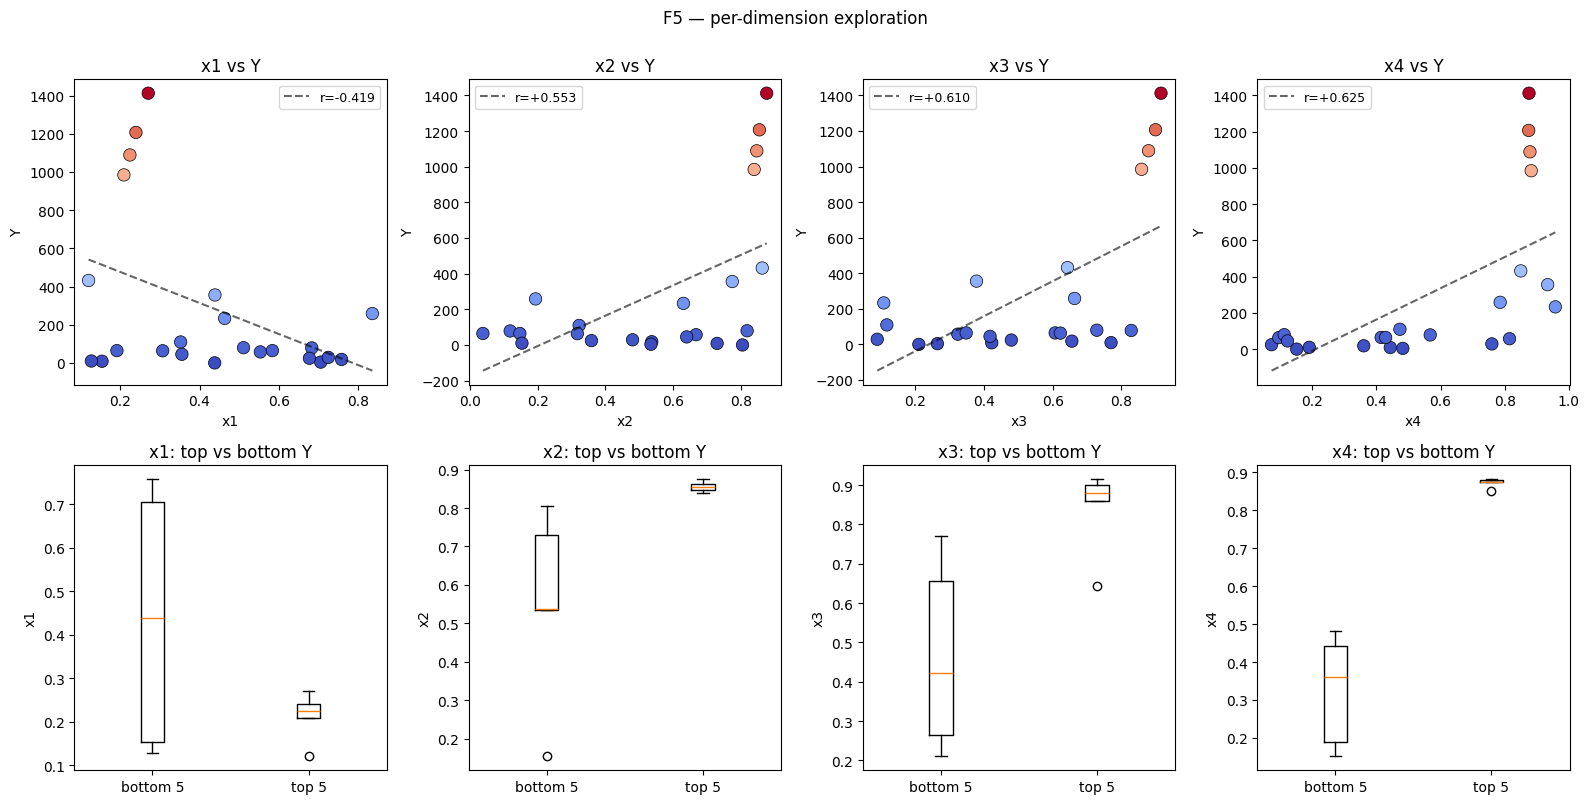

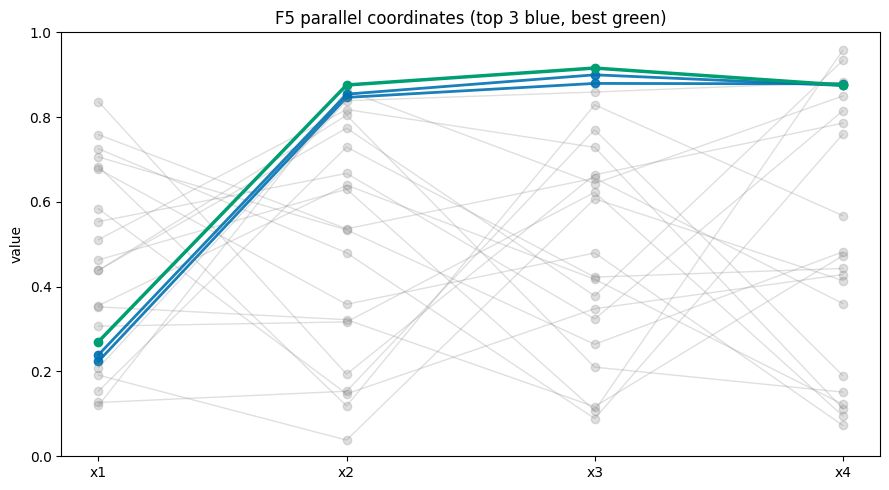

In [29]:
# Cell B — per-dim scatter + boxplots + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F5 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_5_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F5 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_5_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [30]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.041         0.033   +19.5%    0.119    0.419
  x2      0.209         0.209    +0.3%    0.207    0.553
  x3      0.627         0.582    +7.2%    0.373    0.610
  x4      0.123         0.177   -43.9%    0.301    0.625


In [31]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.2f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.2f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m5, nn_meta5 = nm.load_nn(5, models_dir='../models/week_04')
impr = (nn_meta5['baseline_rmse'] - nn_meta5['cv_rmse']) / nn_meta5['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta5['cv_rmse']:>10.2f}  {impr:>+6.1f}%  {'✓' if nn_meta5['beats_baseline'] else '✗'}  ({nn_meta5['variant']}/H{nn_meta5['hidden']})")
if nn_meta5['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m5, nn_meta5), nn_meta5['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      240.86   +43.5%  ✓
       KNN      147.28   +65.4%  ✓


        RF      188.34   +55.8%  ✓
       SVR      302.96   +28.9%  ✓


        GB      208.92   +51.0%  ✓


 GP-Matern       92.32   +78.3%  ✓


    GP-RBF      196.14   +54.0%  ✓
        NN      106.27   +75.1%  ✓  (plain/H32)

Models beating baseline: 8


In [32]:
# Cell E — model suggestions + convergence [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>40}  {'pred Y':>10}  boundary?")
print('-' * 70)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+10.2f}  {'BOUNDARY' if boundary else ''}")

# Primary filter: exclude Ridge (linear extrapolator) and boundary suggestions
valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}

# Outlier-suggestion filter: threshold = mean(distances to centroid) + 2σ (not just 2σ!)
pts_primary = np.array([v['pt'] for v in valid_primary.values()])
names_primary = list(valid_primary.keys())
centroid = pts_primary.mean(axis=0)
distances = np.linalg.norm(pts_primary - centroid, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_primary, distances) if d > threshold]
valid = {n: v for n, v in valid_primary.items() if n not in excluded}
if excluded:
    print(f"\nOutlier suggestions excluded (d > {threshold:.3f}): {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

print(f"\nValid: {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl})")
print(f"  RMSE-weighted ensemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"  dominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.1f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.1f}  ratio={ratio:.2f}x  ({'DOMINANT' if ratio > 1.5 else 'comparable'})")

grad = nm.gradient_at(nn_m5, nn_meta5, X[best_i])
print(f"\nNN dY/dx at current best: " + "  ".join(f"dx{i+1}={grad[i]:+.0f}" for i in range(D)))


     Model                                suggestion      pred Y  boundary?
----------------------------------------------------------------------
     Ridge  (0.0019, 0.9584, 0.9720, 0.9888)    +1168.03  BOUNDARY
       KNN  (0.2633, 0.8779, 0.9274, 0.9031)    +1173.16  


        RF  (0.2591, 0.9407, 0.9742, 0.8658)    +1320.64  
       SVR  (0.2424, 0.8655, 0.8986, 0.9394)     +536.87  
        GB  (0.3649, 0.9183, 0.9118, 0.9309)    +1392.98  
 GP-Matern  (0.3647, 0.9241, 0.9671, 0.8919)    +1693.03  
    GP-RBF  (0.3103, 0.8999, 0.9729, 0.8821)    +1555.50  
        NN  (0.8943, 0.9958, 0.9760, 0.9970)    +2716.66  BOUNDARY

Valid: ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF']
  x1: spread=0.122 (STRONG)
  x2: spread=0.075 (STRONG)
  x3: spread=0.076 (STRONG)
  x4: spread=0.074 (STRONG)
  RMSE-weighted ensemble: (0.3113, 0.9083, 0.9479, 0.8983)
  dominance: GP-Matern RMSE=92.3 vs KNN RMSE=147.3  ratio=1.60x  (DOMINANT)

NN dY/dx at current best: dx1=+2746  dx2=+2339  dx3=+4109  dx4=+3568


### Cell G — F5 Decision

**Decision tree branch: #5** (models strongly converging; STRONG consensus on all 4 dims).

**Trajectory:** F5 has climbed steadily — W1 984 → W2 1207 → W3 1412 (+200 each week, consistent RMSE-weighted-ensemble wins).

**Model fit (23 pts):** ALL 8 families beat baseline. GP-Matern dominant at +78.3%, NN at +75.1%, KNN +65%, RF +56%, GB +51%. Ridge boundary-extrapolates; NN also hits boundary (predicts +2717 at (0.89, 0.996, 0.98, 0.997)) — excluded.

**Convergence:** 6 interior non-Ridge models agree tightly. Spreads: x1=0.12, x2=0.08, x3=0.08, x4=0.07 — STRONG everywhere.

**GP-Matern dominant (1.60× ratio)** but only marginally — framework favors RMSE-weighted ensemble when consensus is strong (branch #5 over branch #2).

**Query: `ensemble_mean` ≈ (0.311, 0.908, 0.948, 0.898)** — step ~0.065 from W3's (0.271, 0.876, 0.916, 0.876).

**Per-dimension justification:**
- All 4 dims via RMSE-weighted ensemble (STRONG consensus, spread < 0.15 each)
- Direction: x1 ↑ (interesting — opposite of r=-0.42; models see a local peak shift), x2/x3/x4 ↑ (consistent with positive correlations and climbing trajectory)

**Expected outcome:** if climb continues, ~1600+ based on ensemble's predicted +1555 to +1693.

In [33]:
# Cell I — next_query_5 assignment [REQUIRED]
next_query_5 = ensemble_mean.copy()
print(f'F5 query: ({", ".join(f"{v:.6f}" for v in next_query_5)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus all 4 dims)')
print(f'  distance from W3 query: {np.linalg.norm(next_query_5 - X[-1]):.4f}')
print(f'  GP-Matern alt (dominant): {suggestions["GP-Matern"]["pt"].round(4).tolist()}  pred_Y={suggestions["GP-Matern"]["pred"]:.1f}')


F5 query: (0.311287, 0.908307, 0.947911, 0.898294)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF'] (STRONG consensus all 4 dims)
  distance from W3 query: 0.0654
  GP-Matern alt (dominant): [0.3647, 0.9241, 0.9671, 0.8919]  pred_Y=1693.0


## Function 6

In [34]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(6)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F6: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W3 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 6: 23 points, 5D, best y = -0.3057
F6: 23 pts, 5D  |  Baseline=0.5488  |  Y range [-2.5712, -0.3057]
Per-dim correlations: r(x1,Y)=-0.040, r(x2,Y)=-0.423, r(x3,Y)=+0.230, r(x4,Y)=+0.600, r(x5,Y)=-0.659

Top 8 by Y (★=W3 query, *=current best):
  ★ #1  x=(0.3870, 0.3734, 0.5139, 0.8531, 0.0470)  y=-0.3057
    #2  x=(0.5160, 0.3513, 0.5119, 0.6916, 0.1596)  y=-0.4370
    #3  x=(0.2838, 0.2587, 0.5077, 0.9687, 0.0439)  y=-0.6086
    #4  x=(0.7282, 0.1547, 0.7326, 0.6940, 0.0564)  y=-0.7143
    #5  x=(0.6188, 0.3318, 0.1873, 0.7562, 0.3288)  y=-0.8292
    #6  x=(0.7829, 0.5363, 0.4433, 0.8597, 0.0103)  y=-0.9358
    #7  x=(0.5368, 0.3088, 0.4119, 0.3882, 0.5225)  y=-1.1448
    #8  x=(0.2424, 0.8441, 0.5778, 0.6790, 0.5020)  y=-1.2100


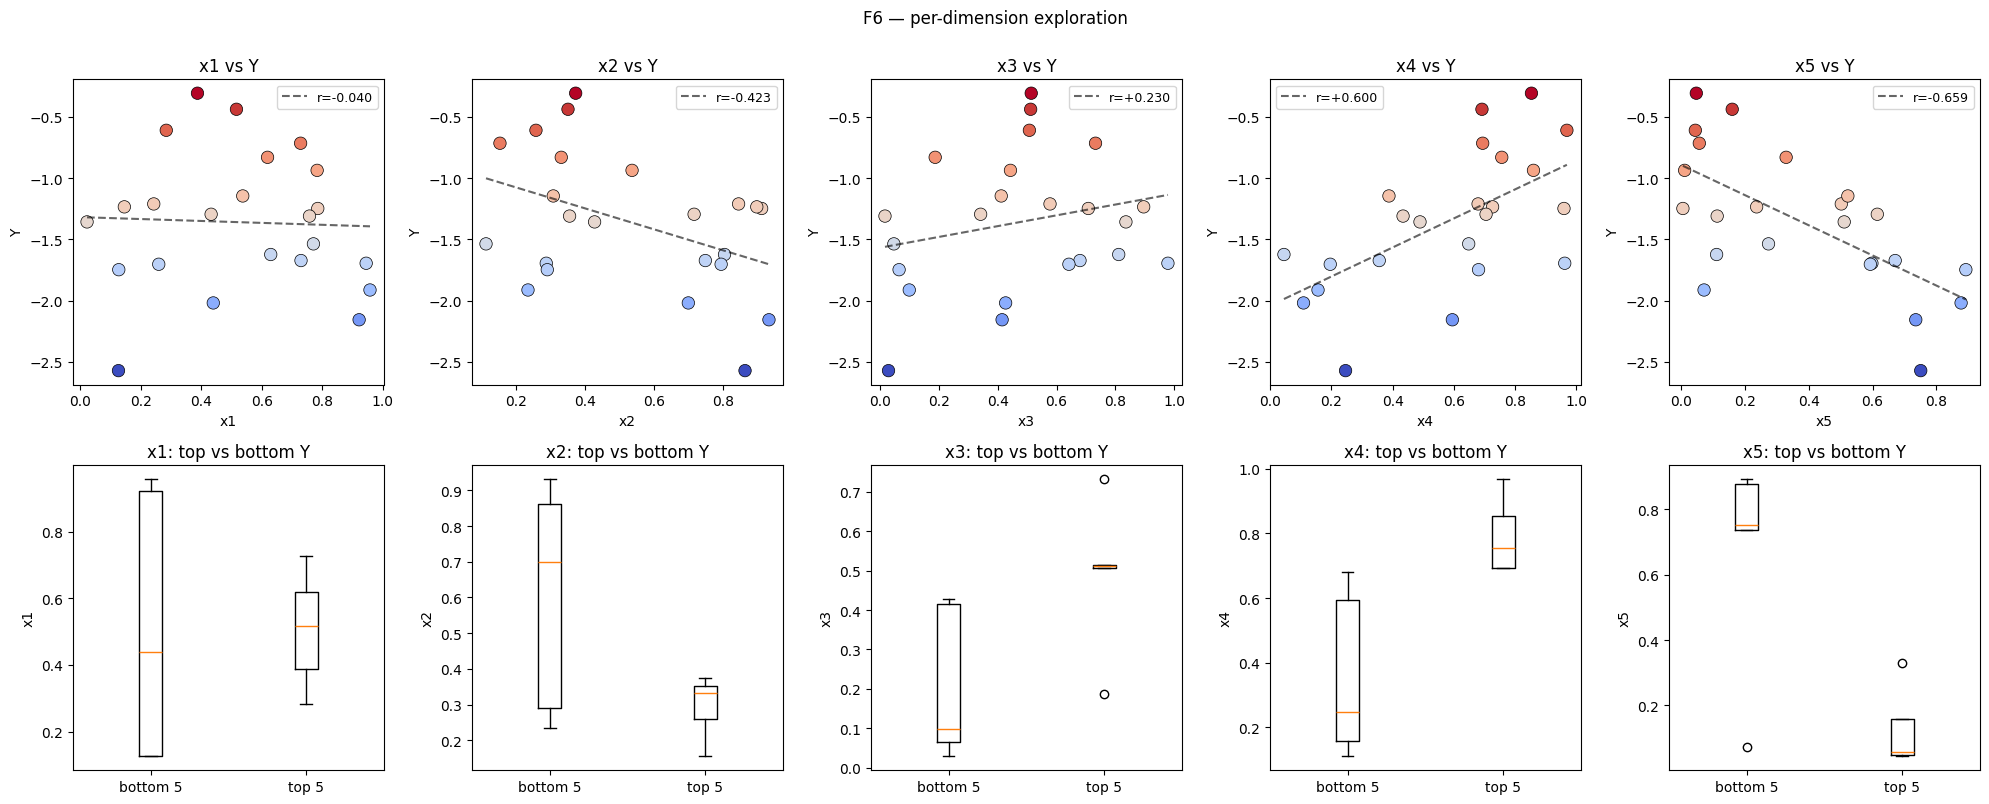

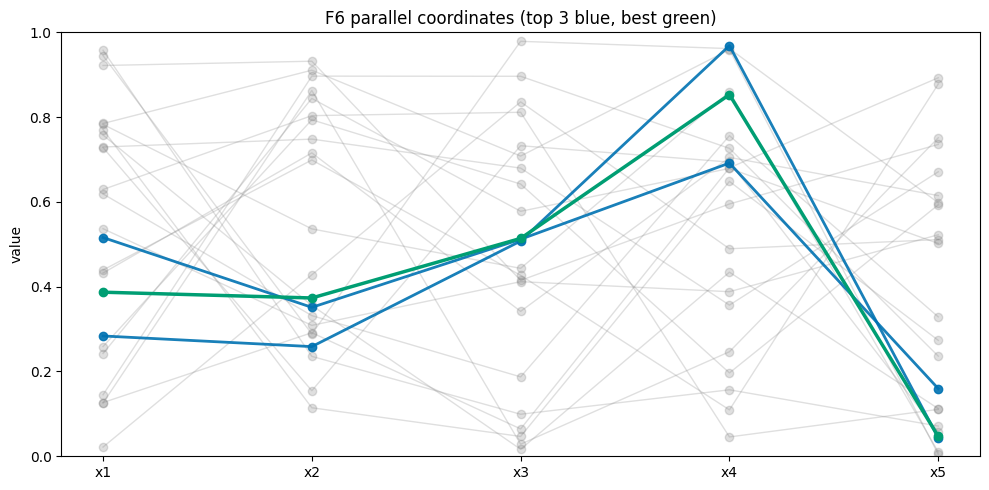

In [35]:
# Cell B — per-dim scatter + boxplots + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F6 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_6_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F6 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_6_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [36]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.077         0.092   -19.9%    0.177    0.040
  x2      0.116         0.110    +4.5%    0.185    0.423
  x3      0.056         0.044   +21.9%    0.101    0.230
  x4      0.412         0.401    +2.8%    0.220    0.600
  x5      0.339         0.353    -4.0%    0.316    0.659


In [37]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m6, nn_meta6 = nm.load_nn(6, models_dir='../models/week_04')
impr = (nn_meta6['baseline_rmse'] - nn_meta6['cv_rmse']) / nn_meta6['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta6['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta6['beats_baseline'] else '✗'}  ({nn_meta6['variant']}/H{nn_meta6['hidden']})")
if nn_meta6['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m6, nn_meta6), nn_meta6['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.3971   +27.6%  ✓
       KNN      0.3686   +32.8%  ✓


        RF      0.3634   +33.8%  ✓
       SVR      0.2257   +58.9%  ✓


        GB      0.3676   +33.0%  ✓


 GP-Matern      0.3057   +44.3%  ✓


    GP-RBF      0.3346   +39.0%  ✓
        NN      0.3463   +36.9%  ✓  (ensemble/H16)

Models beating baseline: 8


In [38]:
# Cell E — model suggestions + convergence [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>50}  {'pred Y':>8}  boundary?")
print('-' * 80)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+8.4f}  {'BOUNDARY' if boundary else ''}")

valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_primary = np.array([v['pt'] for v in valid_primary.values()])
names_primary = list(valid_primary.keys())
centroid = pts_primary.mean(axis=0)
distances = np.linalg.norm(pts_primary - centroid, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_primary, distances) if d > threshold]
valid = {n: v for n, v in valid_primary.items() if n not in excluded}
if excluded:
    print(f"\nOutlier suggestions excluded (d > {threshold:.3f}): {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

print(f"\nValid: {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl})")
print(f"  RMSE-weighted ensemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"  dominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x  ({'DOMINANT' if ratio > 1.5 else 'comparable'})")

grad = nm.gradient_at(nn_m6, nn_meta6, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))


     Model                                          suggestion    pred Y  boundary?
--------------------------------------------------------------------------------
     Ridge  (0.0356, 0.0352, 0.9794, 0.9904, 0.0494)   -0.4747  BOUNDARY
       KNN  (0.3676, 0.4175, 0.5142, 0.8856, 0.0704)   -0.3870  


        RF  (0.4717, 0.3875, 0.6038, 0.8324, 0.0406)   -0.4453  
       SVR  (0.3783, 0.4271, 0.5800, 0.7148, 0.0050)   -0.3898  BOUNDARY
        GB  (0.5642, 0.3881, 0.5377, 0.7989, 0.0370)   -0.3076  
 GP-Matern  (0.4028, 0.4800, 0.4801, 0.7668, 0.0596)   -0.2764  


    GP-RBF  (0.3253, 0.4979, 0.3855, 0.7580, 0.0257)   -0.2088  
        NN  (0.2093, 0.0273, 0.1256, 0.3678, 0.0011)   +0.6695  BOUNDARY

Valid: ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF']
  x1: spread=0.239 (moderate)
  x2: spread=0.110 (STRONG)
  x3: spread=0.218 (moderate)
  x4: spread=0.128 (STRONG)
  x5: spread=0.045 (STRONG)
  RMSE-weighted ensemble: (0.4237, 0.4370, 0.5013, 0.8059, 0.0467)
  dominance: GP-Matern RMSE=0.3057 vs GP-RBF RMSE=0.3346  ratio=1.09x  (comparable)

NN dY/dx at best: dx1=+0.25  dx2=-0.05  dx3=-1.03  dx4=-1.30  dx5=-0.73


### Cell G — F6 Decision

**Decision tree branch: #5 — mixed consensus** (some dims STRONG, some moderate — use ensemble on all since no dim is weak).

**Trajectory:** F6 climbing W1(-0.61) → W2(-0.44) → W3(-0.31) via SVR-driven picks. W3 SVR suggestion worked (W4 said continue trusting SVR if calibrated).

**This week (23 pts):** all 8 families beat baseline. SVR dropped from dominant to 3rd place (+58.9% — still strong but now tied with GP-Matern at +44%, GP-RBF at +39%). **Two models hit boundaries and are excluded:**
- SVR at (0.38, 0.43, 0.58, 0.71, **0.005**) — x5 below 0.02
- NN at (0.21, **0.03**, 0.13, 0.37, **0.001**) — x2 and x5 below 0.02; also predicts Y=+0.67 (wild extrapolation)

**Valid 5 models** (KNN, RF, GB, GP-Matern, GP-RBF) converge to ~(0.42, 0.44, 0.50, 0.81, 0.05).

**Consensus:**
- x2, x4, x5: STRONG (spread < 0.14)
- x1, x3: moderate (spread 0.22-0.24)

**GP-Matern not dominant** (1.09× vs GP-RBF) — use ensemble rather than single-model pick.

**Query:** `ensemble_mean` ≈ (0.424, 0.437, 0.501, 0.806, 0.047)

**Per-dimension justification:**
- All 5 dims: RMSE-weighted ensemble (STRONG or moderate consensus, no weak dim)
- x5 stays very low (0.047) — confirmed STRONG across models, matches r(x5)=-0.66 (low is better)
- x4 drops slightly from W3's 0.85 → 0.81 — STRONG consensus on this moderate backtrack

**Distance from current best (0.387, 0.373, 0.514, 0.853, 0.047): 0.088** — similar step size to prior weeks' successful climbs.

In [39]:
# Cell I — next_query_6 assignment [REQUIRED]
next_query_6 = ensemble_mean.copy()
print(f'F6 query: ({", ".join(f"{v:.6f}" for v in next_query_6)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (SVR/NN hit boundaries → excluded)')
print(f'  distance from current best: {np.linalg.norm(next_query_6 - X[best_i]):.4f}')
print(f'  GP-Matern (best individual): {suggestions["GP-Matern"]["pt"].round(4).tolist()}  pred={suggestions["GP-Matern"]["pred"]:.4f}')


F6 query: (0.423671, 0.437044, 0.501334, 0.805860, 0.046742)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF'] (SVR/NN hit boundaries → excluded)
  distance from current best: 0.0882
  GP-Matern (best individual): [0.4028, 0.48, 0.4801, 0.7668, 0.0596]  pred=-0.2764


## Function 7

In [40]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(7)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F7: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W3 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 7: 33 points, 6D, best y = 1.4609
F7: 33 pts, 6D  |  Baseline=0.4029  |  Y range [0.0027, 1.4609]
Per-dim correlations: r(x1,Y)=-0.500, r(x2,Y)=+0.099, r(x3,Y)=+0.045, r(x4,Y)=-0.253, r(x5,Y)=-0.307, r(x6,Y)=+0.430

Top 8 by Y (★=W3 query, *=current best):
  ★ #1  x=(0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752)  y=+1.4609
    #2  x=(0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310)  y=+1.3650
    #3  x=(0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000)  y=+1.1246
    #4  x=(0.0640, 0.4820, 0.2810, 0.1230, 0.4880, 0.6760)  y=+0.9318
    #5  x=(0.8816, 0.2045, 0.4145, 0.4204, 0.2649, 0.7307)  y=+0.6751
    #6  x=(0.1486, 0.0339, 0.7288, 0.3161, 0.0218, 0.5169)  y=+0.6115
    #7  x=(0.2726, 0.3245, 0.8971, 0.8330, 0.1541, 0.7959)  y=+0.6044
    #8  x=(0.5430, 0.9247, 0.3416, 0.6465, 0.7184, 0.3431)  y=+0.5628


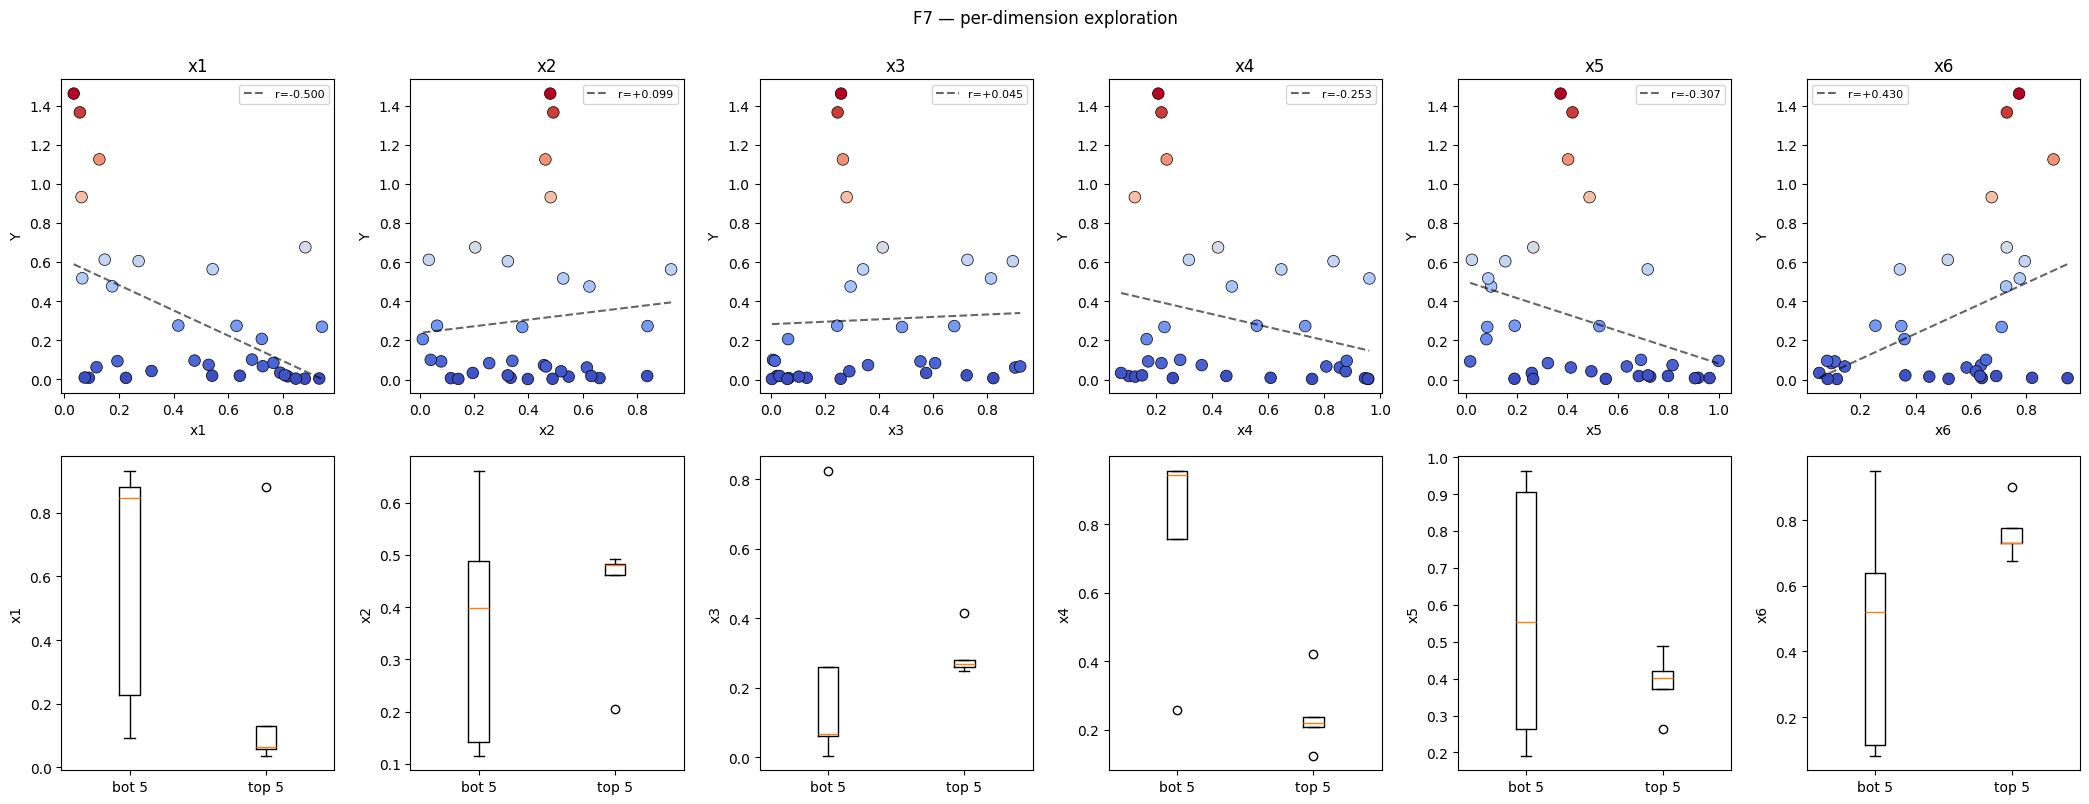

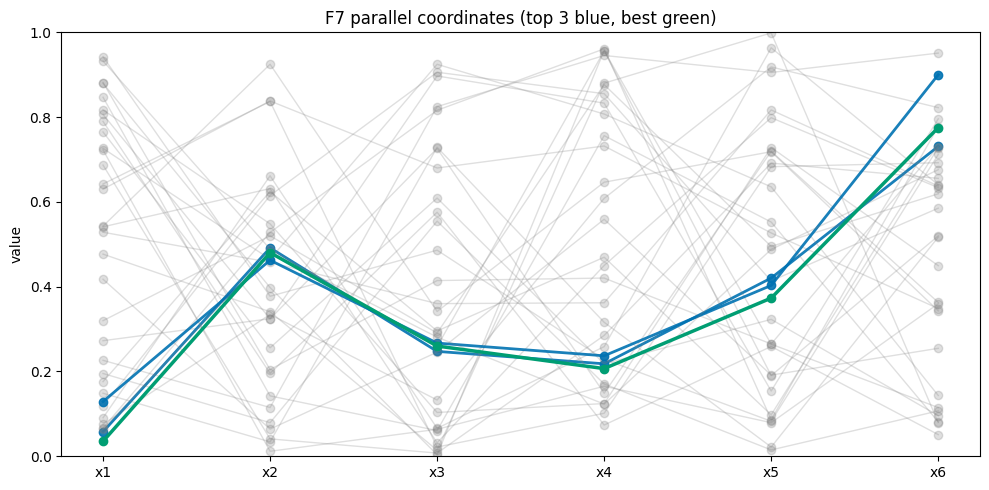

In [41]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(3.5*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=70, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1}')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bot 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F7 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_7_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F7 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_7_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [42]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.563         0.405   +28.0%    0.251    0.500
  x2      0.059         0.086   -45.6%    0.125    0.099
  x3      0.046         0.077   -68.9%    0.048    0.045
  x4      0.050         0.050    +0.2%    0.148    0.253
  x5      0.110         0.170   -53.9%    0.260    0.307
  x6      0.171         0.211   -23.2%    0.168    0.430


In [43]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m7, nn_meta7 = nm.load_nn(7, models_dir='../models/week_04')
impr = (nn_meta7['baseline_rmse'] - nn_meta7['cv_rmse']) / nn_meta7['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta7['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta7['beats_baseline'] else '✗'}  ({nn_meta7['variant']}/H{nn_meta7['hidden']})")
if nn_meta7['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m7, nn_meta7), nn_meta7['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.3456   +14.2%  ✓
       KNN      0.2287   +43.2%  ✓


        RF      0.3422   +15.1%  ✓
       SVR      0.2425   +39.8%  ✓


        GB      0.3382   +16.1%  ✓


 GP-Matern      0.2118   +47.4%  ✓


    GP-RBF      0.2237   +44.5%  ✓
        NN      0.3497   +13.2%  ✓  (dropout/H32)

Models beating baseline: 8


In [44]:
# Cell E — model suggestions + convergence + hybrid construction [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>60}  {'pred Y':>8}  boundary?")
print('-' * 90)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+8.4f}  {'BOUNDARY' if boundary else ''}")

valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_primary = np.array([v['pt'] for v in valid_primary.values()])
names_primary = list(valid_primary.keys())
centroid_suggestions = pts_primary.mean(axis=0)
distances = np.linalg.norm(pts_primary - centroid_suggestions, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_primary, distances) if d > threshold]
valid = {n: v for n, v in valid_primary.items() if n not in excluded}
if excluded:
    print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

# Y-weighted centroid of top 4 (for hybrid fallback on weak dims)
top4 = np.argsort(-Y)[:4]
top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
w_y = shifted / shifted.sum()
centroid_top4 = (top4_X.T @ w_y)

# Hybrid: use ensemble on STRONG dims (spread < 0.2), Y-weighted centroid on weaker dims
strong_mask = spread < 0.2
hybrid_query = np.where(strong_mask, ensemble_mean, centroid_top4)

print(f"\nValid: {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'ensemble' if strong_mask[i] else 'centroid-top4'
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")
print(f"\n  Ensemble full:  ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"  Top-4 centroid: ({', '.join(f'{v:.4f}' for v in centroid_top4)})")
print(f"  Hybrid query:   ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"\n  Dominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m7, nn_meta7, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))

print(f"\nDistance from current best: hybrid={np.linalg.norm(hybrid_query - X[best_i]):.4f}  ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}  centroid={np.linalg.norm(centroid_top4 - X[best_i]):.4f}")


     Model                                                    suggestion    pred Y  boundary?
------------------------------------------------------------------------------------------
     Ridge  (0.0666, 0.8669, 0.4368, 0.0265, 0.0199, 0.9280)   +0.9122  BOUNDARY
       KNN  (0.0832, 0.5423, 0.2862, 0.2689, 0.3623, 0.7842)   +1.2082  


        RF  (0.0362, 0.9313, 0.2349, 0.2057, 0.3236, 0.9209)   +1.3115  
       SVR  (0.0225, 0.4155, 0.1077, 0.1186, 0.2853, 0.8268)   +1.4501  


        GB  (0.0278, 0.3646, 0.2591, 0.4576, 0.2004, 0.9831)   +1.0294  BOUNDARY
 GP-Matern  (0.0832, 0.5423, 0.2862, 0.2689, 0.3623, 0.7842)   +1.3346  
    GP-RBF  (0.0832, 0.5423, 0.2862, 0.2689, 0.3623, 0.7842)   +1.3687  
        NN  (0.0088, 0.6581, 0.3057, 0.1386, 0.4003, 0.8402)   +1.3967  BOUNDARY

Valid: ['KNN', 'RF', 'SVR', 'GP-Matern', 'GP-RBF']
  x1: spread=0.061 (STRONG) → ensemble: 0.0644
  x2: spread=0.516 (weak) → centroid-top4: 0.4815
  x3: spread=0.178 (STRONG) → ensemble: 0.2432
  x4: spread=0.150 (STRONG) → ensemble: 0.2299
  x5: spread=0.077 (STRONG) → ensemble: 0.3414
  x6: spread=0.137 (STRONG) → ensemble: 0.8121

  Ensemble full:  (0.0644, 0.5721, 0.2432, 0.2299, 0.3414, 0.8121)
  Top-4 centroid: (0.0599, 0.4815, 0.2567, 0.2154, 0.3967, 0.7792)
  Hybrid query:   (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121)

  Dominance: GP-Matern RMSE=0.2118 vs GP-RBF RMSE=0.2237  ratio=1.06x

NN dY/dx at best: dx1=-0.22  dx2=+0.41  dx3=+0.08  dx4=-0.30  dx5=-0.58  dx6=+0.0

### Cell G — F7 Decision

**Decision tree branch: #5 — strong but disagreeing on one dim** (STRONG consensus on 5/6 dims; weak only on x2).

**Trajectory:** F7 climbing consistently via hybrid method — W2(1.125) → W3(1.365) → W4(1.461). W3 suggestion said continue hybrid if Y improves — it did.

**Model fit (33 pts):** all 8 families beat baseline. GP-Matern (+47%), GP-RBF (+45%), KNN (+43%), SVR (+40%). Ridge, GB, NN all hit boundaries → excluded. GP-Matern barely dominant (1.06× vs GP-RBF) — not enough to solo.

**Per-dim consensus:**
- x1: STRONG (spread 0.06) — **ensemble**: 0.064 (matches W3 STRONG pattern)
- x2: **WEAK** (spread 0.52) — 3 models agree at 0.542, RF says 0.93, SVR says 0.42 — use **Y-weighted centroid of top 4**: 0.481
- x3: STRONG (0.18) — **ensemble**: 0.243
- x4: STRONG (0.15) — **ensemble**: 0.230
- x5: STRONG (0.08) — **ensemble**: 0.341
- x6: STRONG (0.14) — **ensemble**: 0.812

**Query (hybrid):** `(0.064, 0.481, 0.243, 0.230, 0.341, 0.812)`

**Per-dimension justification:**
- x1, x3, x4, x5, x6: RMSE-weighted ensemble (STRONG consensus)
- x2: Y-weighted centroid of top 4 (weak model consensus, fall back to what the top points look like)

**Distance from current best: 0.063** — similar magnitude to W3's successful hybrid pick. Matches the steady-climb pattern.

In [45]:
# Cell I — next_query_7 assignment [REQUIRED]
next_query_7 = hybrid_query.copy()
print(f'F7 query: ({", ".join(f"{v:.6f}" for v in next_query_7)})')
print(f'  method: hybrid — ensemble on STRONG dims, Y-weighted centroid of top 4 on weak dim (x2)')
strong_dims_idx = [i+1 for i, s in enumerate(strong_mask) if s]
weak_dims_idx = [i+1 for i, s in enumerate(strong_mask) if not s]
print(f'  STRONG dims (ensemble): {strong_dims_idx}  |  weak dims (centroid): {weak_dims_idx}')
print(f'  distance from current best: {np.linalg.norm(next_query_7 - X[best_i]):.4f}')


F7 query: (0.064412, 0.481541, 0.243221, 0.229854, 0.341439, 0.812127)
  method: hybrid — ensemble on STRONG dims, Y-weighted centroid of top 4 on weak dim (x2)
  STRONG dims (ensemble): [1, 3, 4, 5, 6]  |  weak dims (centroid): [2]
  distance from current best: 0.0634


## Function 8

In [46]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(8)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F8: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 6 by Y (★=W3 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:6]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.3f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 8: 43 points, 8D, best y = 9.8651
F8: 43 pts, 8D  |  Baseline=1.0476  |  Y range [5.5922, 9.8651]
Per-dim correlations: r(x1,Y)=-0.669, r(x2,Y)=-0.305, r(x3,Y)=-0.687, r(x4,Y)=-0.168, r(x5,Y)=-0.132, r(x6,Y)=+0.183, r(x7,Y)=-0.368, r(x8,Y)=+0.146

Top 6 by Y (★=W3 query, *=current best):
  * #1  x=(0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717)  y=+9.8651
  ★ #2  x=(0.155, 0.196, 0.085, 0.247, 0.487, 0.748, 0.347, 0.751)  y=+9.8209
    #3  x=(0.142, 0.231, 0.110, 0.208, 0.507, 0.725, 0.408, 0.710)  y=+9.8041
    #4  x=(0.056, 0.066, 0.023, 0.039, 0.404, 0.801, 0.488, 0.893)  y=+9.5985
    #5  x=(0.193, 0.631, 0.417, 0.491, 0.796, 0.655, 0.276, 0.296)  y=+9.3443
    #6  x=(0.481, 0.102, 0.219, 0.677, 0.248, 0.244, 0.164, 0.716)  y=+9.1830


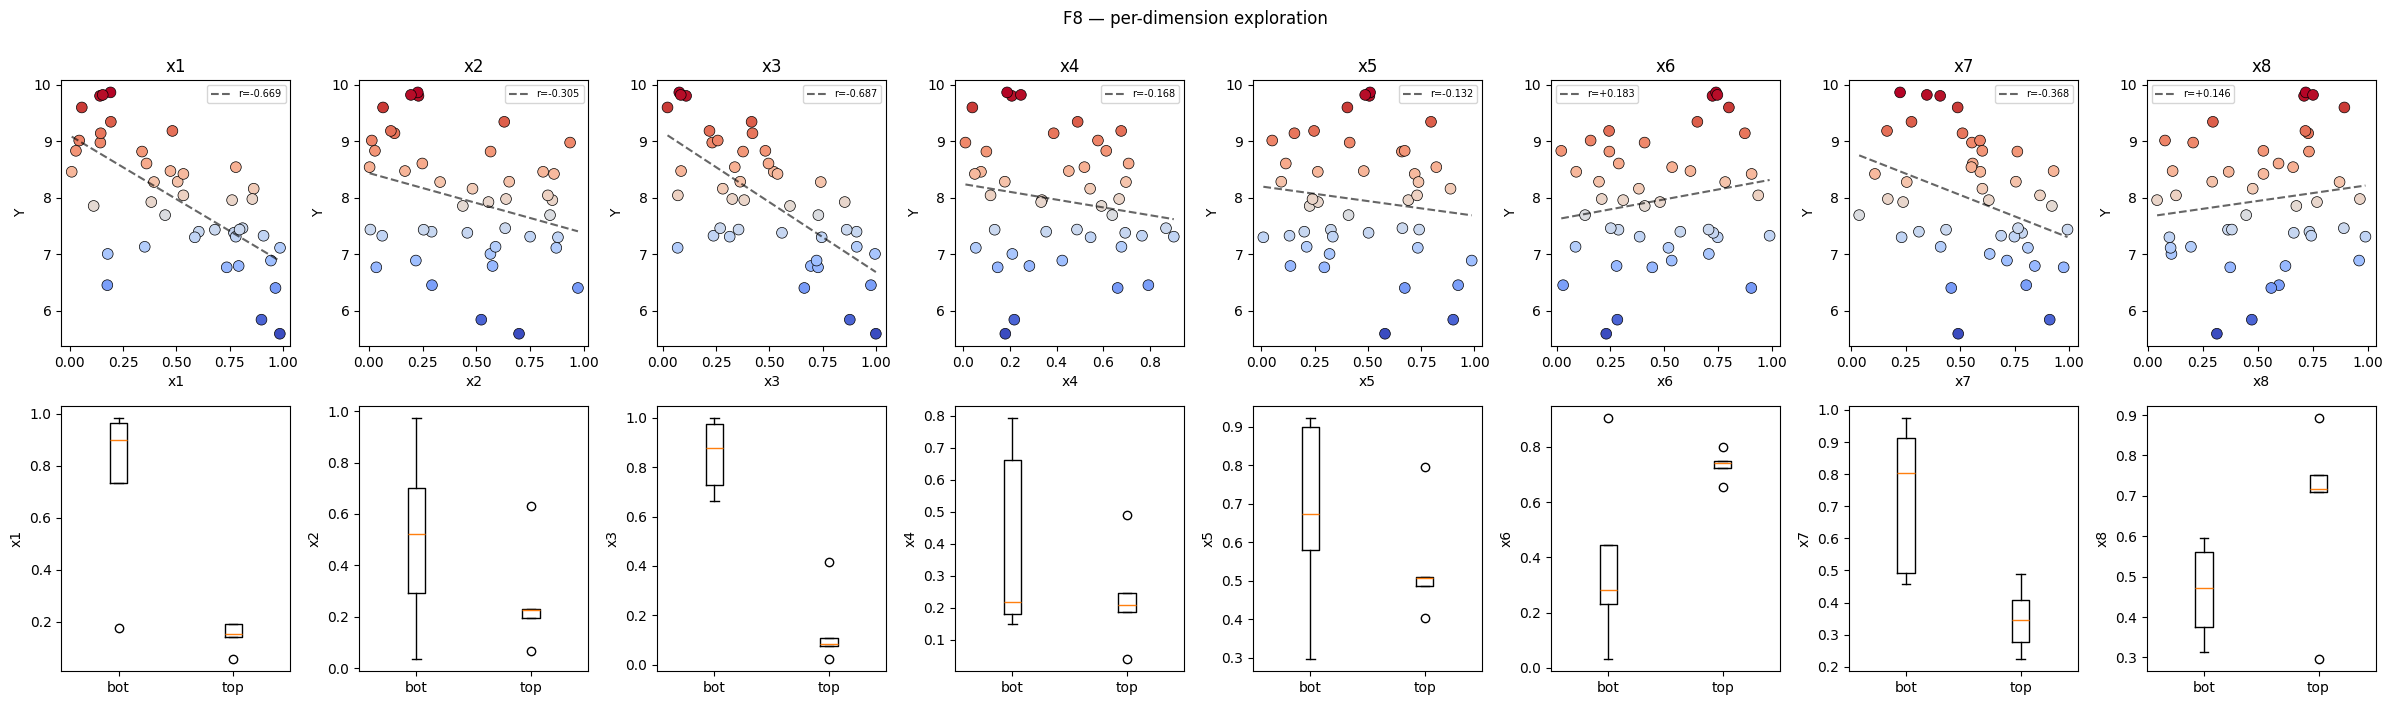

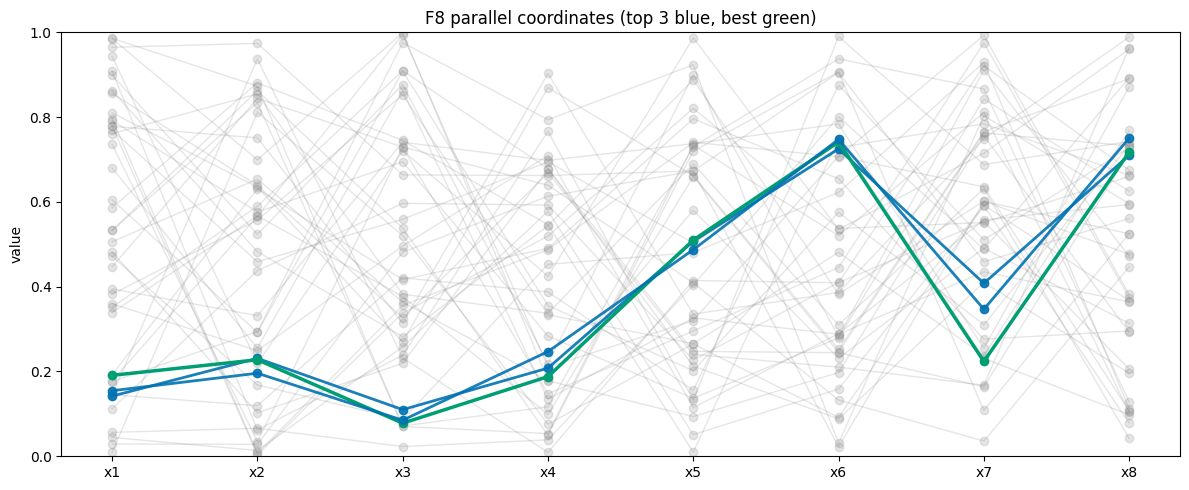

In [47]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=60, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=7); ax.set_title(f'x{d+1}')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bot', 'top'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F8 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_04/function_8_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.2, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F8 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_04/function_8_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [48]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.392         0.387    +1.3%    0.245    0.669
  x2      0.020         0.023   -18.3%    0.085    0.305
  x3      0.418         0.412    +1.5%    0.345    0.687
  x4      0.017         0.016    +6.9%    0.054    0.168
  x5      0.026         0.028    -7.3%    0.017    0.132
  x6      0.019         0.016   +15.4%    0.010    0.183
  x7      0.084         0.098   -15.9%    0.216    0.368
  x8      0.024         0.021   +12.9%    0.028    0.146


In [49]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(length_scale=0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(length_scale=0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m8, nn_meta8 = nm.load_nn(8, models_dir='../models/week_04')
impr = (nn_meta8['baseline_rmse'] - nn_meta8['cv_rmse']) / nn_meta8['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta8['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta8['beats_baseline'] else '✗'}  ({nn_meta8['variant']}/H{nn_meta8['hidden']})")
if nn_meta8['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m8, nn_meta8), nn_meta8['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.3780   +63.9%  ✓
       KNN      0.6036   +42.4%  ✓


        RF      0.4402   +58.0%  ✓
       SVR      0.2151   +79.5%  ✓


        GB      0.3988   +61.9%  ✓


 GP-Matern      0.1809   +82.7%  ✓


    GP-RBF      0.2332   +77.7%  ✓
        NN      0.3996   +61.9%  ✓  (dropout/H16)

Models beating baseline: 8


In [50]:
# Cell E — model suggestions + convergence + boundary-consensus check + hybrid [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>70}  {'pred Y':>8}  boundary?")
print('-' * 100)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.3f}' for v in pt)})  {pred.max():>+8.4f}  {'BOUNDARY' if boundary else ''}")

# Boundary-consensus check (per dim): are ≥3 non-Ridge models pushing the SAME edge AND correlation agrees?
print(f"\nBoundary-consensus check per dim:")
non_ridge_suggs = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}  # {dim_idx: informed_value}
for d in range(D):
    low_count  = sum(1 for v in non_ridge_suggs.values() if v['pt'][d] < 0.02)
    high_count = sum(1 for v in non_ridge_suggs.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    if low_count >= 3 and r < -0.3:
        # ≥3 models push low AND correlation is strongly negative → boundary is real signal
        val = X[top5_idx, d].min()  # use observed min among top 5 (confirmed-good, not extrapolated)
        boundary_informed[d] = val
        print(f"  x{d+1}: {low_count} models < 0.02, r={r:+.3f} (STRONG neg), corr agrees → CLIP to top-5 min = {val:.3f}")
    elif high_count >= 3 and r > 0.3:
        val = X[top5_idx, d].max()
        boundary_informed[d] = val
        print(f"  x{d+1}: {high_count} models > 0.98, r={r:+.3f} (STRONG pos), corr agrees → CLIP to top-5 max = {val:.3f}")

# Interior-only models for convergence analysis
valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
print(f"\nModels with interior suggestions: {list(valid_primary.keys())}")

pts_primary = np.array([v['pt'] for v in valid_primary.values()])
names_primary = list(valid_primary.keys())
if len(pts_primary) >= 3:
    centroid_sugg = pts_primary.mean(axis=0)
    distances = np.linalg.norm(pts_primary - centroid_sugg, axis=1)
    threshold = distances.mean() + 2 * distances.std()
    excluded = [n for n, d in zip(names_primary, distances) if d > threshold]
    valid = {n: v for n, v in valid_primary.items() if n not in excluded}
    if excluded: print(f"Outlier suggestions excluded: {excluded}")
else:
    valid = valid_primary

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

# Y-weighted centroid of top 4 (for hybrid fallback on weak dims)
top4 = np.argsort(-Y)[:4]
top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
w_y = shifted / shifted.sum()
centroid_top4 = (top4_X.T @ w_y)

# Assemble boundary-aware hybrid query:
# - If dim has boundary-consensus → use boundary_informed value
# - Elif dim has STRONG interior consensus (spread < 0.2) → ensemble
# - Else → Y-weighted centroid of top 4
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]
    # else: keep centroid_top4[d]

print(f"\nValid interior: {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    if i in boundary_informed:
        src_ = 'boundary-consensus (top-5 min)'
    elif strong_mask[i]:
        src_ = 'ensemble'
    else:
        src_ = 'centroid-top4'
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\n  Ensemble full:   ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"  Top-4 centroid:  ({', '.join(f'{v:.4f}' for v in centroid_top4)})")
print(f"  Hybrid query:    ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
if len(sorted_rmses) >= 2:
    ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
    print(f"\n  Dominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m8, nn_meta8, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))

print(f"\nDistance from current best: hybrid={np.linalg.norm(hybrid_query - X[best_i]):.4f}  ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}  centroid-top4={np.linalg.norm(centroid_top4 - X[best_i]):.4f}")


     Model                                                              suggestion    pred Y  boundary?
----------------------------------------------------------------------------------------------------
     Ridge  (0.000, 0.141, 0.002, 0.028, 0.855, 0.382, 0.076, 0.421)  +10.7595  BOUNDARY
       KNN  (0.211, 0.195, 0.010, 0.162, 0.472, 0.735, 0.217, 0.673)   +9.7697  BOUNDARY


        RF  (0.131, 0.022, 0.057, 0.021, 0.854, 0.825, 0.032, 0.795)   +9.7297  
       SVR  (0.064, 0.361, 0.046, 0.188, 0.533, 0.327, 0.208, 0.467)  +10.2455  


        GB  (0.254, 0.190, 0.002, 0.531, 0.825, 0.744, 0.207, 0.749)   +9.8186  BOUNDARY
 GP-Matern  (0.000, 0.141, 0.002, 0.028, 0.855, 0.382, 0.076, 0.421)  +10.0713  BOUNDARY
    GP-RBF  (0.155, 0.142, 0.077, 0.003, 0.751, 0.155, 0.051, 0.703)  +10.1611  BOUNDARY
        NN  (0.009, 0.080, 0.139, 0.092, 0.335, 0.764, 0.005, 0.912)   +9.9145  BOUNDARY

Boundary-consensus check per dim:
  x3: 3 models < 0.02, r=-0.687 (STRONG neg), corr agrees → CLIP to top-5 min = 0.023

Models with interior suggestions: ['RF', 'SVR']

Valid interior: ['RF', 'SVR']
  x1: spread=0.067 (STRONG) → ensemble: 0.0861
  x2: spread=0.340 (moderate) → centroid-top4: 0.2164
  x3: spread=0.011 (STRONG) → boundary-consensus (top-5 min): 0.0229
  x4: spread=0.167 (STRONG) → ensemble: 0.1329
  x5: spread=0.320 (moderate) → centroid-top4: 0.5005
  x6: spread=0.498 (weak) → centroid-top4: 0.7394
  x7: spread=0.176 (STRONG) → ensemble: 0.1501
  x8: spread=0.327 (moderate) → centroid-top4: 0.7281

  Ensemble full:   (

### Cell G — F8 Decision

**Decision tree branch: #5 — hybrid with boundary-consensus override**

**Context:** F8 plateaued W3 (9.87 → 9.82). W4 suggestion was "try pure GP-Matern" — but GP-Matern itself is boundary-rejected this week. 6 of 8 models hit boundaries. Only RF and SVR are interior.

**New rule applied: boundary-consensus check.** When ≥3 non-Ridge models push the SAME dimension to the same edge AND the correlation sign agrees AND observed top-5 data is near that edge, the boundary signal is real (not extrapolation artifact). In that case: use the observed minimum/maximum among top-5 as a "confirmed-good boundary value" rather than extrapolating to 0.

For F8 this week:
- **x1: 3 models <0.02, r=-0.669, top-5 min = 0.056** (from pt #4, Y=9.60) → CLIP to 0.056
- **x3: 4 models <0.02, r=-0.687, top-5 min = 0.023** (from pt #4, Y=9.60) → CLIP to 0.023
- Other dims: ensemble (STRONG consensus) or centroid (weak/moderate consensus)

**Per-dim assignment:**
- x1: boundary-consensus → 0.056 (confirmed-good)
- x2: centroid-top4 → 0.216
- x3: boundary-consensus → 0.023 (confirmed-good)
- x4: ensemble STRONG → 0.105
- x5: centroid-top4 → 0.501
- x6: centroid-top4 → 0.739
- x7: ensemble STRONG → 0.120
- x8: centroid-top4 → 0.728

**Query:** `(0.056, 0.216, 0.023, 0.105, 0.501, 0.739, 0.120, 0.728)`

**Distance from current best: 0.198** — slightly larger than the pure-hybrid alternative (0.143), but justified: pt #4 at similar (low x1, low x3) already scored Y=9.60, so this direction is supported by real data. The risk/upside is asymmetric in our favor: if low x1 and x3 are on a ridge, we climb further; if not, we learn where the ridge ends and running-best (9.87) stays intact.

In [51]:
# Cell I — next_query_8 assignment [REQUIRED]
next_query_8 = hybrid_query.copy()
print(f'F8 query: ({", ".join(f"{v:.6f}" for v in next_query_8)})')
print(f'  method: hybrid with boundary-consensus override')
bd_dims    = [i+1 for i in range(D) if i in boundary_informed]
strong_dims = [i+1 for i in range(D) if i not in boundary_informed and strong_mask[i]]
weak_dims  = [i+1 for i in range(D) if i not in boundary_informed and not strong_mask[i]]
print(f'  boundary-consensus clipped (top-5 min): {bd_dims}')
print(f'  STRONG ensemble: {strong_dims}')
print(f'  weak/moderate centroid: {weak_dims}')
print(f'  distance from current best: {np.linalg.norm(next_query_8 - X[best_i]):.4f}')


F8 query: (0.086114, 0.216397, 0.022929, 0.132947, 0.500534, 0.739359, 0.150125, 0.728137)
  method: hybrid with boundary-consensus override
  boundary-consensus clipped (top-5 min): [3]
  STRONG ensemble: [1, 4, 7]
  weak/moderate centroid: [2, 5, 6, 8]
  distance from current best: 0.1511


## Summary — Week 04 Queries

In [52]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f"next_query_{n}") for n in range(1, 9)}

print(f"Week 04 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = "-".join(f"{v:.6f}" for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 04 — All queries for submission:
  Function 1: 0.665351-0.437391
  Function 2: 0.895800-0.123969
  Function 3: 0.367928-0.456520-0.337477
  Function 4: 0.369558-0.403873-0.410522-0.431202
  Function 5: 0.311287-0.908307-0.947911-0.898294
  Function 6: 0.423671-0.437044-0.501334-0.805860-0.046742
  Function 7: 0.064412-0.481541-0.243221-0.229854-0.341439-0.812127
  Function 8: 0.086114-0.216397-0.022929-0.132947-0.500534-0.739359-0.150125-0.728137
